# Employee Attrition Prediction - Production Notebook

## 0. Environment Setup & Imports

This section installs and imports all required packages, sets reproducibility seeds, and defines global constants.
It also prints package versions for traceability in production and experiments.

In [ ]:
import sys
import warnings
import importlib
from pathlib import Path
from typing import Dict, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def optional_import(module_name: str):
    """Import a module safely and return None if unavailable."""
    try:
        return importlib.import_module(module_name)
    except Exception:
        return None

msno = optional_import('missingno')

from scipy.stats import chi2_contingency, pointbiserialr

lifelines_mod = optional_import('lifelines')
KaplanMeierFitter = getattr(lifelines_mod, 'KaplanMeierFitter', None)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, auc, f1_score, brier_score_loss
 )
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

xgb_mod = optional_import('xgboost')
XGBClassifier = getattr(xgb_mod, 'XGBClassifier', None)

catboost_mod = optional_import('catboost')
CatBoostClassifier = getattr(catboost_mod, 'CatBoostClassifier', None)

imblearn_os_mod = optional_import('imblearn.over_sampling')
SMOTE = getattr(imblearn_os_mod, 'SMOTE', None)

optuna = optional_import('optuna')
shap = optional_import('shap')

lime_tabular_mod = optional_import('lime.lime_tabular')
LimeTabularExplainer = getattr(lime_tabular_mod, 'LimeTabularExplainer', None)

fairlearn_metrics = optional_import('fairlearn.metrics')
MetricFrame = getattr(fairlearn_metrics, 'MetricFrame', None)
selection_rate = getattr(fairlearn_metrics, 'selection_rate', None)
true_positive_rate = getattr(fairlearn_metrics, 'true_positive_rate', None)
false_positive_rate = getattr(fairlearn_metrics, 'false_positive_rate', None)

transformers_mod = optional_import('transformers')
pipeline = getattr(transformers_mod, 'pipeline', None)

import joblib

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **_kwargs):
        _ = _kwargs
        return iterable

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15
DATA_DIR = Path('PS2')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

TARGET_COL = None
JOIN_KEY = None
TEXT_COL = None
PRIMARY_DATASET = None


Optional dependency install failures (pipeline will skip related sections if needed):
- fairlearn: Command '['c:\\Users\\MQFJ5881\\OneDrive - orange.com\\Bureau\\Hackathon\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-q', 'fairlearn']' returned non-zero exit status 1.
- bertopic: Command '['c:\\Users\\MQFJ5881\\OneDrive - orange.com\\Bureau\\Hackathon\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-q', 'bertopic']' returned non-zero exit status 1.
Python: 3.14.4
Pandas: 2.3.3
NumPy: 2.4.4
Scikit-learn: 1.8.0
XGBoost: 3.2.0
Optuna: 4.8.0


## 1. Data Loading & Discovery

This section inspects every dataset file in the project and dynamically discovers the join key, target label, and open-text feedback column.
The pipeline logic is then configured from these findings to avoid hardcoded assumptions.

In [ ]:
def load_csv_safe(path: Path) -> pd.DataFrame:
    """Load a CSV safely with informative errors."""
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')
    try:
        return pd.read_csv(path)
    except Exception as exc:
        raise RuntimeError(f'Failed to read {path}: {exc}') from exc

def discover_assets(data_dir: Path) -> Tuple[Dict[str, pd.DataFrame], Dict[str, Any]]:
    """Discover datasets and infer modeling metadata (summary only)."""
    csv_files = sorted(data_dir.glob('*.csv'))
    if not csv_files:
        raise RuntimeError(f'No CSV files found in {data_dir.resolve()}')

    data = {}
    for fp in csv_files:
        data[fp.name] = load_csv_safe(fp)

    # infer join key
    id_candidates = {}
    for name, df in data.items():
        cols = [c for c in df.columns if 'id' in c.lower()]
        id_candidates[name] = cols

    common_cols = set.intersection(*[set(df.columns) for df in data.values()]) if len(data) > 1 else set(next(iter(data.values())).columns)
    join_key = None
    for c in common_cols:
        if 'id' in c.lower():
            join_key = c
            break

    if join_key is None:
        flatten = [c for cols in id_candidates.values() for c in cols]
        join_key = pd.Series(flatten).value_counts().index[0] if flatten else None

    # infer target
    target_col = None
    primary_dataset = None
    for name, df in data.items():
        for c in df.columns:
            vals = df[c].dropna().unique()
            if 'attrition' in c.lower() and len(vals) == 2:
                target_col = c
                primary_dataset = name
                break
        if target_col:
            break

    # infer text col (avg length > 30)
    text_col = None
    text_dataset = None
    best_avg = 0.0
    for name, df in data.items():
        obj_cols = df.select_dtypes(include=['object', 'string']).columns
        for c in obj_cols:
            avg_len = df[c].dropna().astype(str).str.len().mean() if df[c].notna().sum() else 0
            if avg_len > 30 and avg_len > best_avg:
                best_avg = float(avg_len)
                text_col = c
                text_dataset = name

    supplementary = [n for n in data.keys() if n != primary_dataset]

    metadata = {
        'join_key': join_key,
        'target_col': target_col,
        'text_col': text_col,
        'text_dataset': text_dataset,
        'primary_dataset': primary_dataset,
        'supplementary_datasets': supplementary
    }
    return data, metadata

raw_data, discovery = discover_assets(DATA_DIR)

JOIN_KEY = discovery['join_key']
TARGET_COL = discovery['target_col']
TEXT_COL = discovery['text_col']
PRIMARY_DATASET = discovery['primary_dataset']

print('\n' + '='*90)
print('DISCOVERY SUMMARY')
print('='*90)
print('Primary dataset:', PRIMARY_DATASET)
print('Supplementary datasets:', discovery['supplementary_datasets'])
print('Join key:', JOIN_KEY)
print('Target column:', TARGET_COL)
print('Text column:', TEXT_COL, f"(from {discovery['text_dataset']})" if discovery['text_dataset'] else '')
print('Target is binary:', raw_data[PRIMARY_DATASET][TARGET_COL].dropna().nunique() == 2)

Dataset: attrition_data.csv
Shape: (10000, 3)

Dtypes:
Employee_ID         object
Attrition_Status    object
Attrition_Date      object
dtype: object

Head:


,Employee_ID,Attrition_Status,Attrition_Date
0,E10001,No,NaN
1,E10002,No,NaN
2,E10003,Yes,2023-06-11
3,E10004,Yes,2023-10-22
4,E10005,No,NaN



Null counts:


,null_count
Attrition_Date,8192
Employee_ID,0
Attrition_Status,0



Categorical unique counts:
  - Employee_ID: 10000
  - Attrition_Status: 2
  - Attrition_Date: 729
Dataset: compensation_data.csv
Shape: (10000, 5)

Dtypes:
Employee_ID           object
Base_Salary            int64
Bonus                  int64
Stock_Options          int64
Total_Compensation     int64
dtype: object

Head:


...


Categorical unique counts:
  - Role: 33
  - Location: 9
  - Data_Source: 5
Dataset: survey_results.csv
Shape: (10000, 7)

Dtypes:
Employee_ID            object
Job_Satisfaction      float64
Work_Life_Balance     float64
Management_Support    float64
Career_Development    float64
Engagement_Level      float64
Feedback_Comments      object
dtype: object

Head:


,Employee_ID,Job_Satisfaction,Work_Life_Balance,Management_Support,Career_Development,Engagement_Level,Feedback_Comments
0,E10001,4.3,4.0,3.7,3.2,3.6,Salary is decent but bonuses could be better.
1,E10002,3.6,2.7,3.7,2.3,3.1,Work is okay but growth opportunities are limi...
2,E10003,5.0,3.1,4.4,3.2,3.8,"Very happy with my role, learning a lot every ..."
3,E10004,2.9,3.6,2.5,3.5,3.2,Workload is sometimes heavy but manageable.
4,E10005,4.9,2.2,4.2,3.3,3.9,Excellent team culture and flexible hours.



Null counts:


,null_count
Employee_ID,0
Job_Satisfaction,0
Work_Life_Balance,0
Management_Support,0
Career_Development,0
Engagement_Level,0
Feedback_Comments,0



Categorical unique counts:
  - Employee_ID: 10000
  - Feedback_Comments: 25

DISCOVERY SUMMARY
Primary dataset: attrition_data.csv
Supplementary datasets: ['compensation_data.csv', 'employee_data.csv', 'market_benchmarks.csv', 'survey_results.csv']
Join key: Employee_ID
Target column: Attrition_Status
Text column: Feedback_Comments (from survey_results.csv)
Target is binary: True

Engineered features we CAN build: {'compa_ratio': True, 'promotion_velocity_gap': False, 'manager_stability_index': False, 'tenure_band': True}

Sections/parts expected to be skipped:
- Promotion Velocity Gap: missing promotion timing columns.
- Manager Stability Index: missing manager change history columns.


In [ ]:
def merge_datasets(data: Dict[str, pd.DataFrame], join_key: str) -> pd.DataFrame:
    """Merge all datasets into a unified employee-level table."""
    if PRIMARY_DATASET is None:
        raise RuntimeError('Primary dataset could not be identified.')

    merged = data[PRIMARY_DATASET].copy()

    for name, df in data.items():
        if name == PRIMARY_DATASET:
            continue

        if join_key in df.columns:
            merged = merged.merge(df, on=join_key, how='left', suffixes=('', f"_{name.split('.')[0]}"))
        elif {'Role', 'Work_Location'}.issubset(merged.columns) and {'Role', 'Location'}.issubset(df.columns):
            merged = merged.merge(df, left_on=['Role', 'Work_Location'], right_on=['Role', 'Location'], how='left')

    return merged


df = merge_datasets(raw_data, JOIN_KEY)

# Standardize target to 0/1
if df[TARGET_COL].dtype == 'object':
    mapping = {'yes': 1, 'no': 0, 'true': 1, 'false': 0, 'left': 1, 'stay': 0}
    df[TARGET_COL + '_bin'] = df[TARGET_COL].astype(str).str.strip().str.lower().map(mapping)
else:
    df[TARGET_COL + '_bin'] = df[TARGET_COL]

df = df[df[TARGET_COL + '_bin'].isin([0, 1])].copy()
df[TARGET_COL + '_bin'] = df[TARGET_COL + '_bin'].astype(int)

target_rate = df[TARGET_COL + '_bin'].mean() * 100

Merged compensation_data.csv on Employee_ID: rows 10000 -> 10000
Merged employee_data.csv on Employee_ID: rows 10000 -> 10000
Merged market_benchmarks.csv on [Role, Work_Location]=[Role, Location]: rows 10000 -> 10000
Merged survey_results.csv on Employee_ID: rows 10000 -> 10000

Final unified shape: (10000, 25)


### Show Merged Dataset Head
Here is the head of the merged dataset.

In [22]:
display(df.head())

,Employee_ID,Attrition_Status,Attrition_Date,Base_Salary,Bonus,Stock_Options,Total_Compensation,Age,Gender,Department,...,Location,Benchmark_Salary,Data_Source,Job_Satisfaction,Work_Life_Balance,Management_Support,Career_Development,Engagement_Level,Feedback_Comments,Attrition_Status_bin
0,E10001,No,NaN,120646,10032,3758,134436,38,Male,Marketing,...,Seattle,103303,Levels.fyi,4.3,4.0,3.7,3.2,3.6,Salary is decent but bonuses could be better.,0
1,E10002,No,NaN,87447,10342,3360,101149,35,Female,Customer Support,...,Austin,83502,Glassdoor,3.6,2.7,3.7,2.3,3.1,Work is okay but growth opportunities are limi...,0
2,E10003,Yes,2023-06-11,92222,5466,2496,100184,35,Female,Operations,...,Denver,73332,Glassdoor,5.0,3.1,4.4,3.2,3.8,"Very happy with my role, learning a lot every ...",1
3,E10004,Yes,2023-10-22,114022,9363,7212,130597,24,Male,Finance,...,Seattle,121961,Bureau of Labor Statistics,2.9,3.6,2.5,3.5,3.2,Workload is sometimes heavy but manageable.,1
4,E10005,No,NaN,148880,5614,25296,179790,48,Female,Engineering,...,Austin,106560,Bureau of Labor Statistics,4.9,2.2,4.2,3.3,3.9,Excellent team culture and flexible hours.,0


## 2. Exploratory Data Analysis (EDA)

This section quantifies and visualizes attrition patterns across categorical and numerical drivers.
It also runs statistical significance checks and survival analysis when tenure data is available.

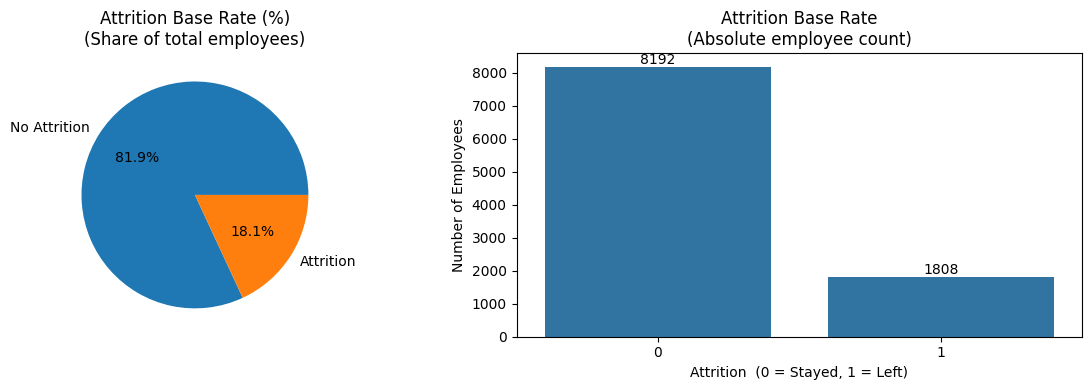

Interpretation: Pie shows % share; bar shows raw headcount. A large imbalance between the two bars means the model will need class-weighting or resampling.


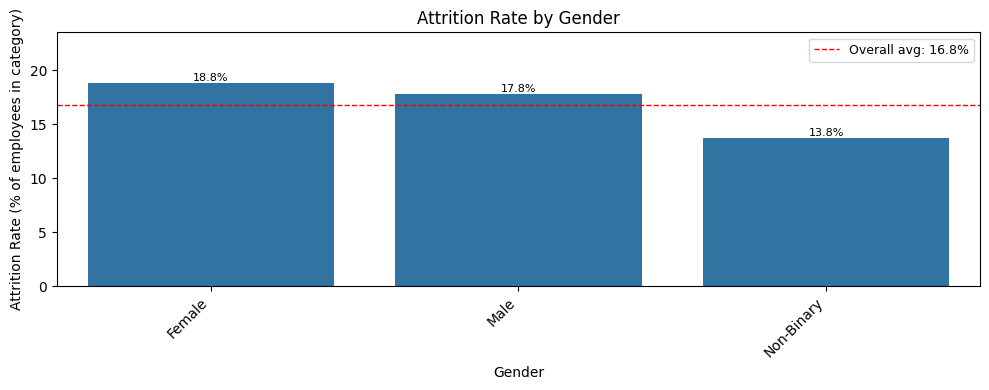

Interpretation: Y-axis = % of employees in each Gender category who left. Red dashed line = overall average. Top 3 highest-risk: {'Female': 18.8, 'Male': 17.8, 'Non-Binary': 13.8}


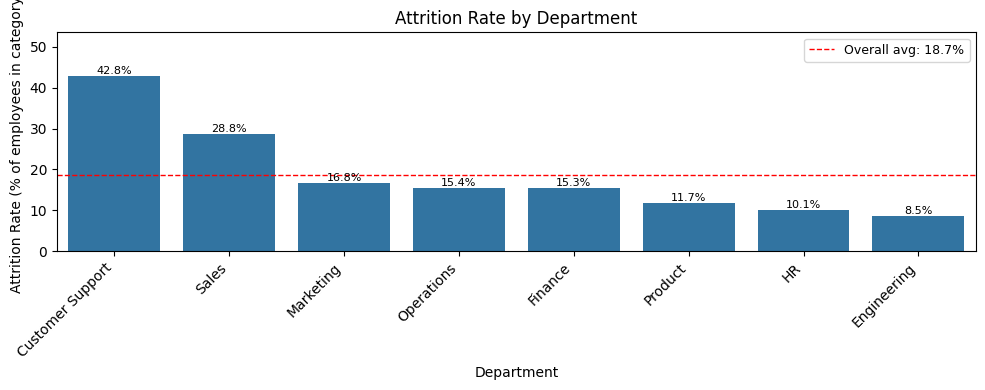

Interpretation: Y-axis = % of employees in each Department category who left. Red dashed line = overall average. Top 3 highest-risk: {'Customer Support': 42.8, 'Sales': 28.8, 'Marketing': 16.8}


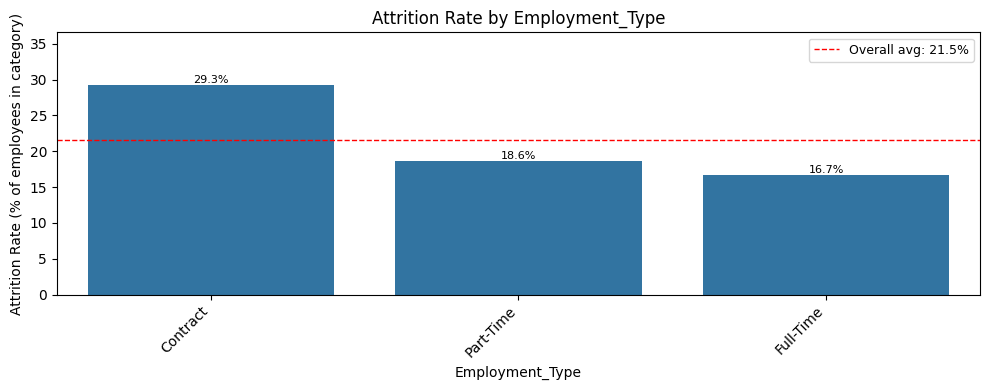

Interpretation: Y-axis = % of employees in each Employment_Type category who left. Red dashed line = overall average. Top 3 highest-risk: {'Contract': 29.3, 'Part-Time': 18.6, 'Full-Time': 16.7}


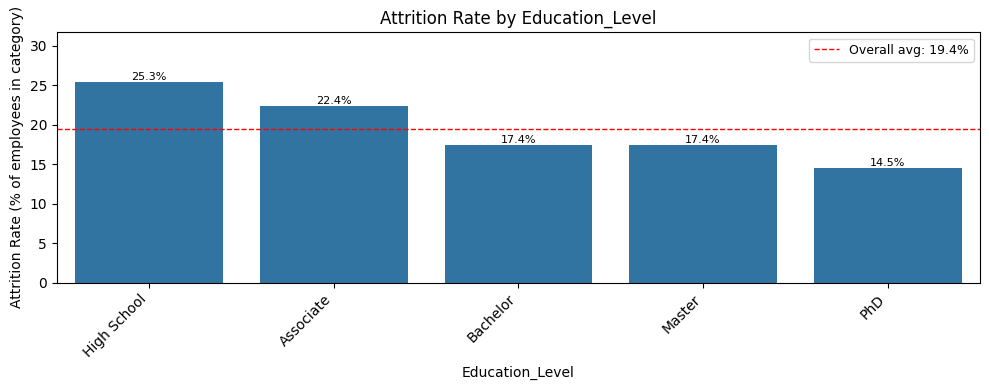

Interpretation: Y-axis = % of employees in each Education_Level category who left. Red dashed line = overall average. Top 3 highest-risk: {'High School': 25.3, 'Associate': 22.4, 'Bachelor': 17.4}


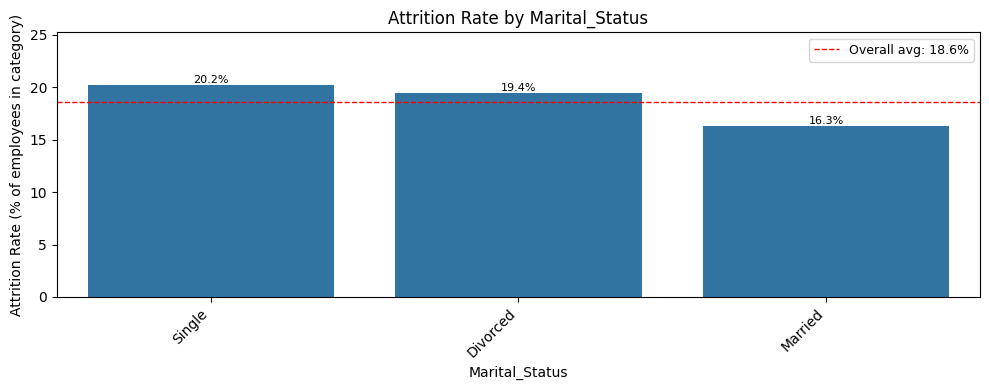

Interpretation: Y-axis = % of employees in each Marital_Status category who left. Red dashed line = overall average. Top 3 highest-risk: {'Single': 20.2, 'Divorced': 19.4, 'Married': 16.3}


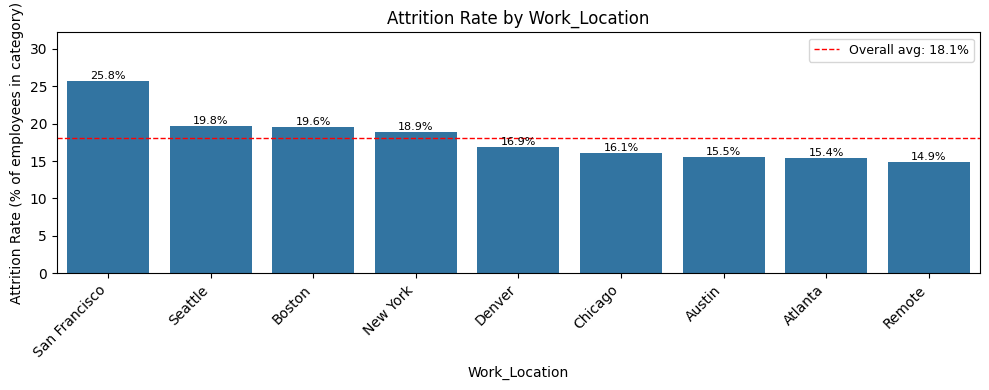

Interpretation: Y-axis = % of employees in each Work_Location category who left. Red dashed line = overall average. Top 3 highest-risk: {'San Francisco': 25.8, 'Seattle': 19.8, 'Boston': 19.6}


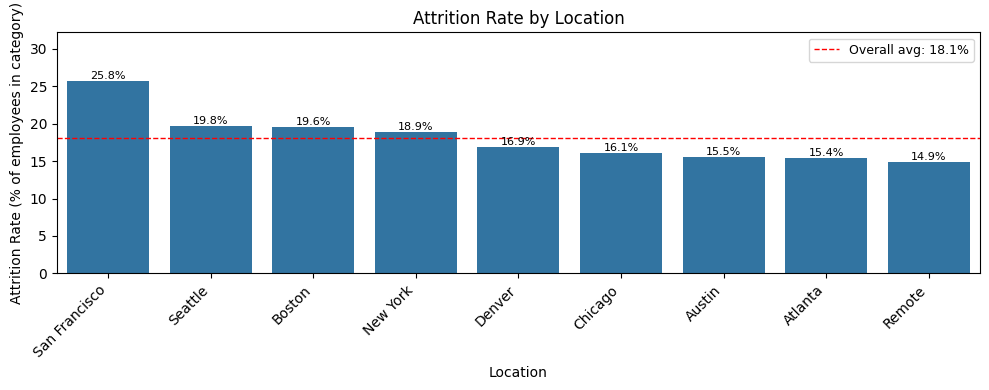

Interpretation: Y-axis = % of employees in each Location category who left. Red dashed line = overall average. Top 3 highest-risk: {'San Francisco': 25.8, 'Seattle': 19.8, 'Boston': 19.6}


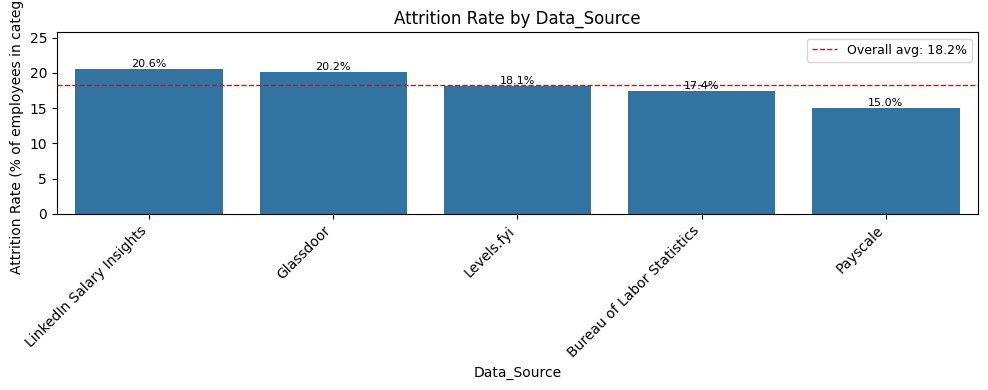

Interpretation: Y-axis = % of employees in each Data_Source category who left. Red dashed line = overall average. Top 3 highest-risk: {'LinkedIn Salary Insights': 20.6, 'Glassdoor': 20.2, 'Levels.fyi': 18.1}


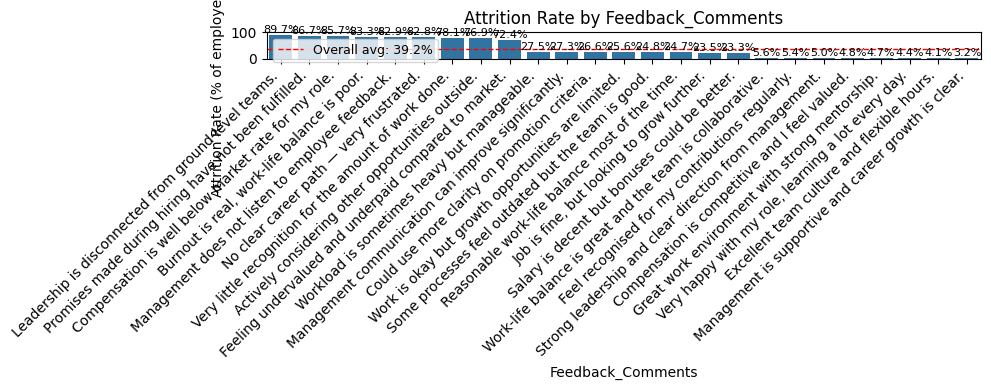

Interpretation: Y-axis = % of employees in each Feedback_Comments category who left. Red dashed line = overall average. Top 3 highest-risk: {'Leadership is disconnected from ground-level teams.': 89.7, 'Promises made during hiring have not been fulfilled.': 86.7, 'Compensation is well below market rate for my role.': 85.7}


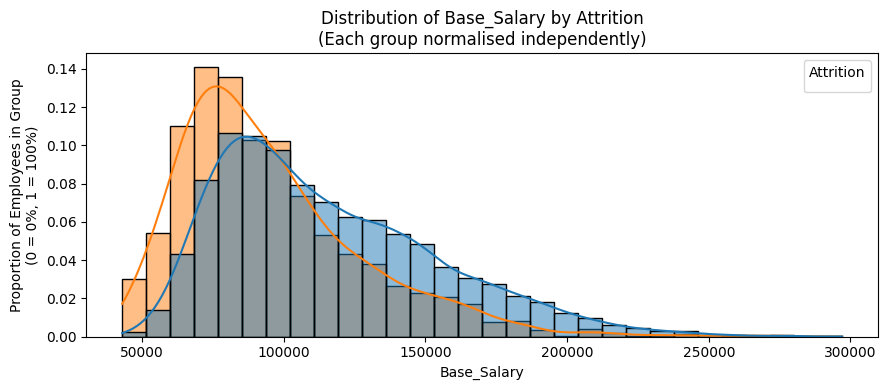

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Base_Salary bin. Peaks at different x-positions signal that Base_Salary differs between leavers and stayers.


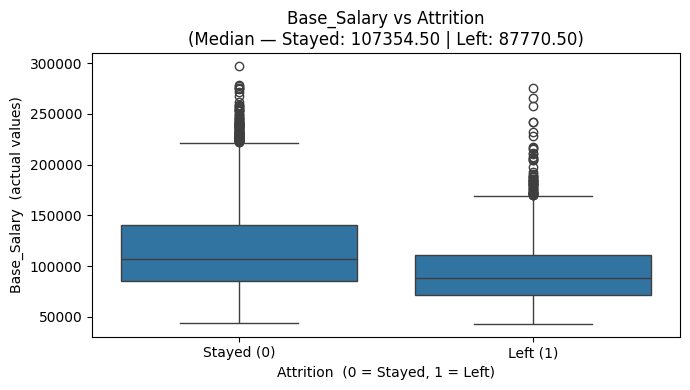

Interpretation: Y-axis = actual Base_Salary values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


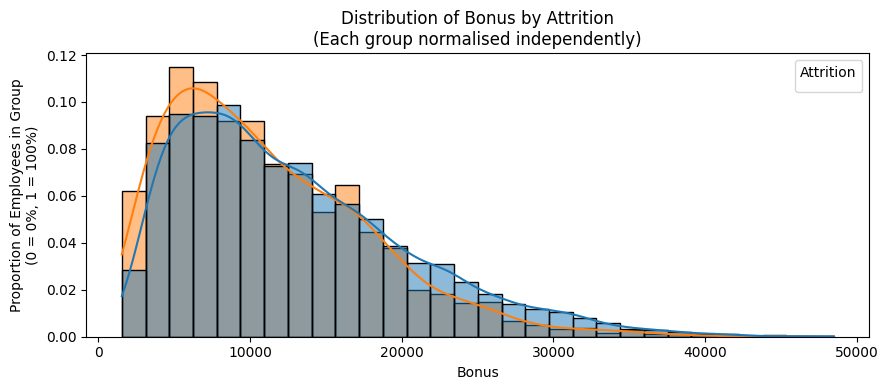

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Bonus bin. Peaks at different x-positions signal that Bonus differs between leavers and stayers.


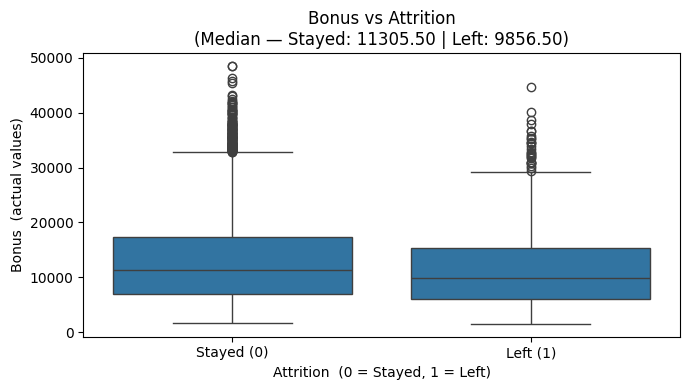

Interpretation: Y-axis = actual Bonus values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


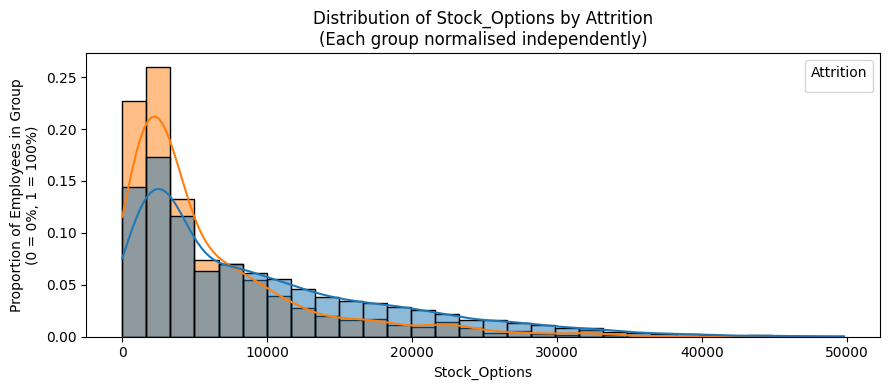

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Stock_Options bin. Peaks at different x-positions signal that Stock_Options differs between leavers and stayers.


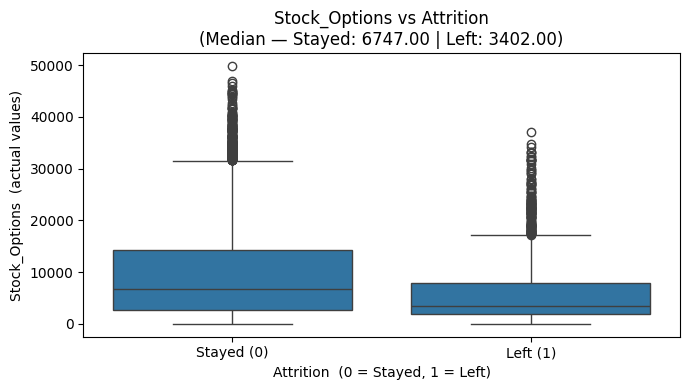

Interpretation: Y-axis = actual Stock_Options values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


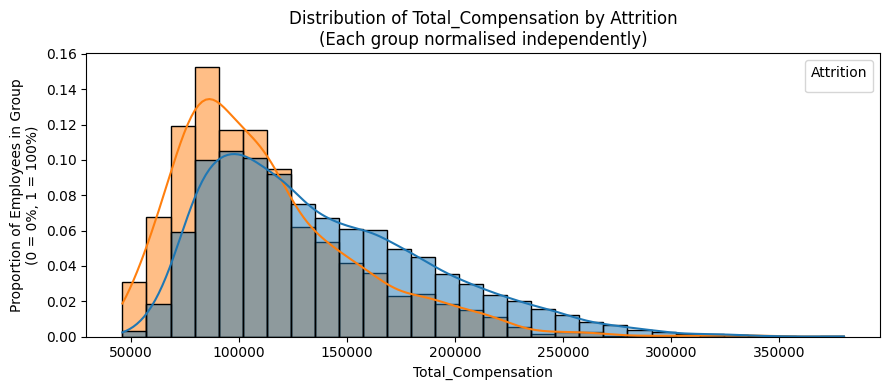

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Total_Compensation bin. Peaks at different x-positions signal that Total_Compensation differs between leavers and stayers.


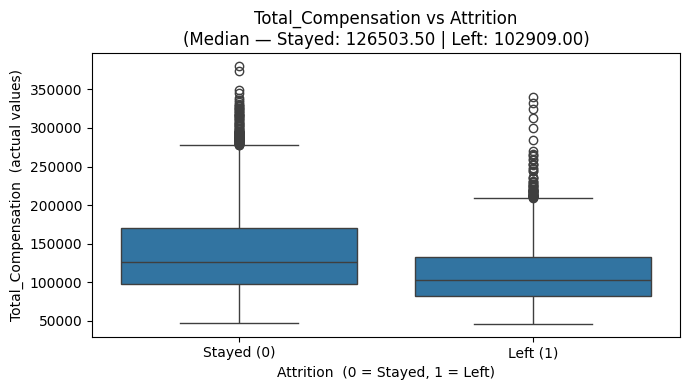

Interpretation: Y-axis = actual Total_Compensation values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


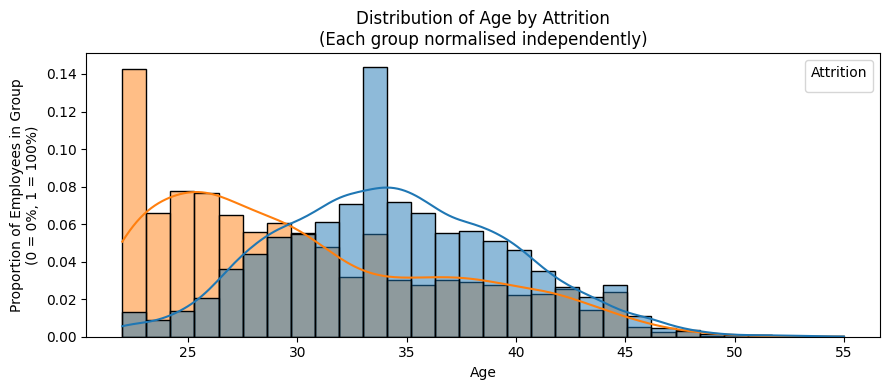

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Age bin. Peaks at different x-positions signal that Age differs between leavers and stayers.


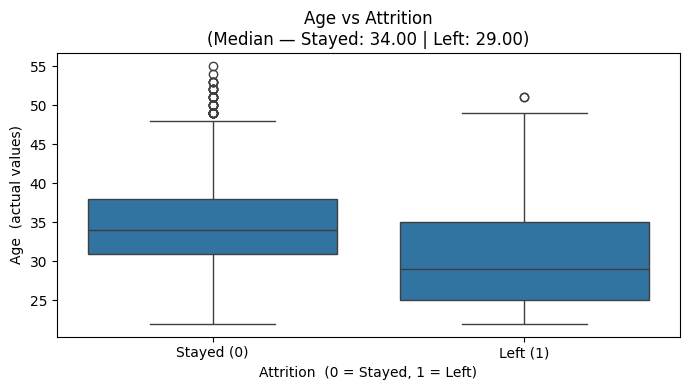

Interpretation: Y-axis = actual Age values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


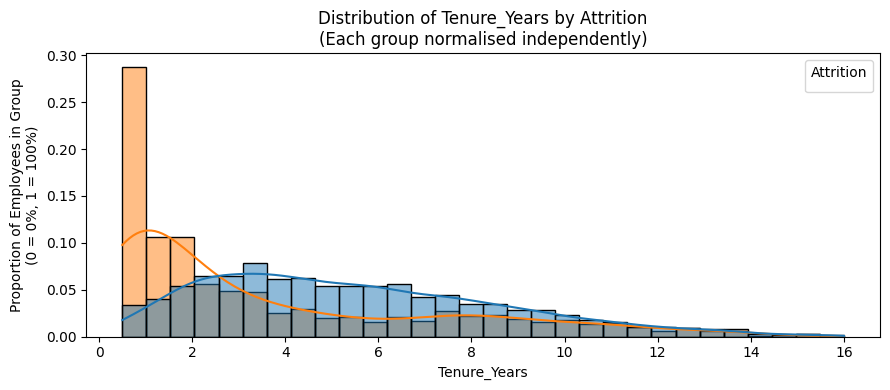

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Tenure_Years bin. Peaks at different x-positions signal that Tenure_Years differs between leavers and stayers.


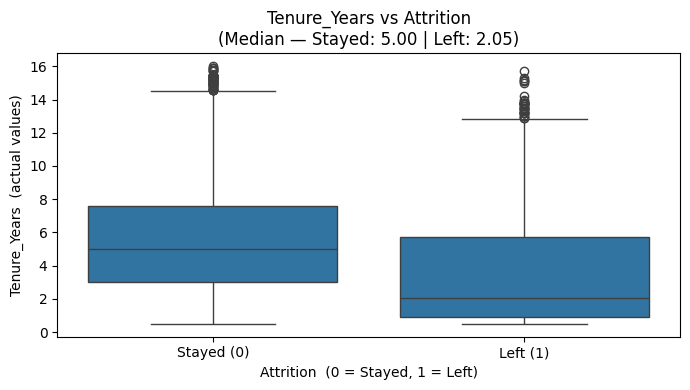

Interpretation: Y-axis = actual Tenure_Years values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


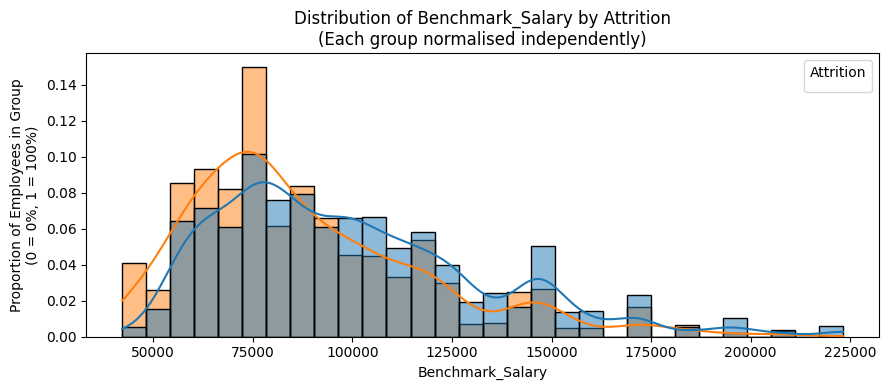

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Benchmark_Salary bin. Peaks at different x-positions signal that Benchmark_Salary differs between leavers and stayers.


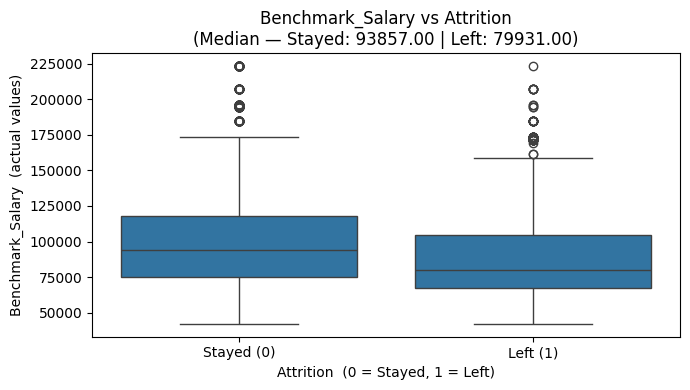

Interpretation: Y-axis = actual Benchmark_Salary values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


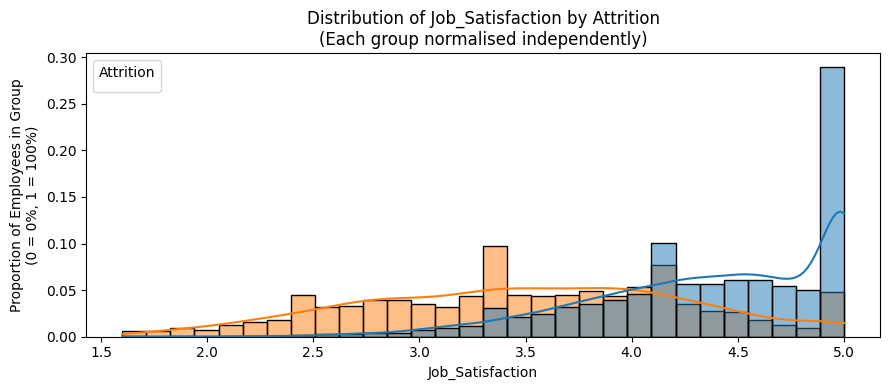

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Job_Satisfaction bin. Peaks at different x-positions signal that Job_Satisfaction differs between leavers and stayers.


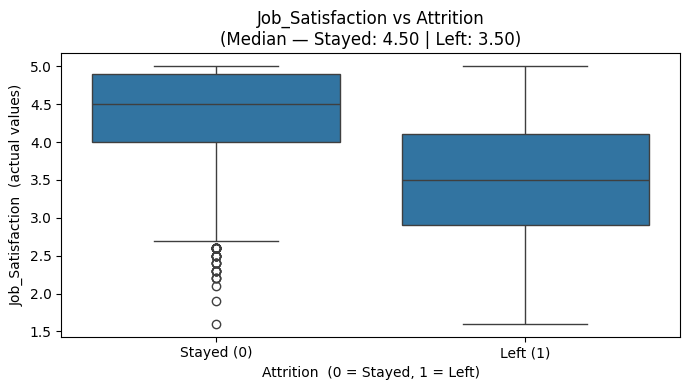

Interpretation: Y-axis = actual Job_Satisfaction values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


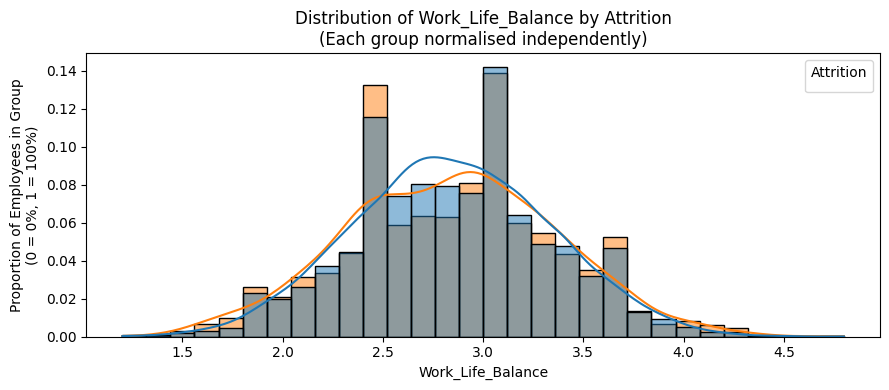

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Work_Life_Balance bin. Peaks at different x-positions signal that Work_Life_Balance differs between leavers and stayers.


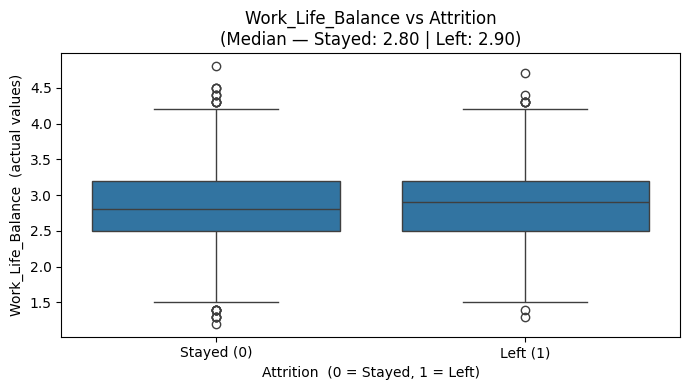

Interpretation: Y-axis = actual Work_Life_Balance values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


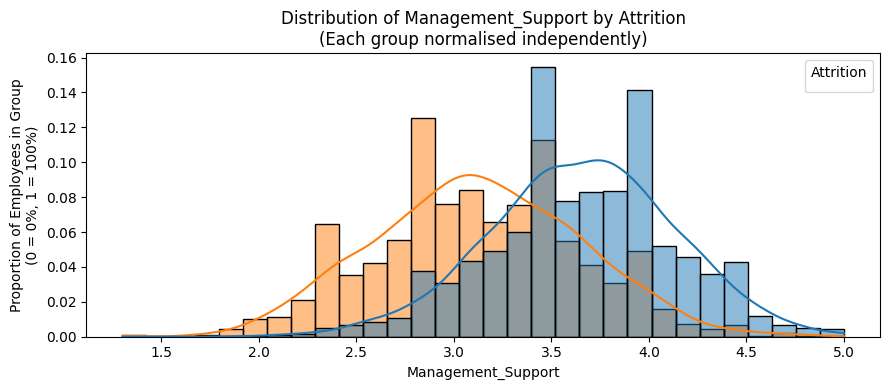

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Management_Support bin. Peaks at different x-positions signal that Management_Support differs between leavers and stayers.


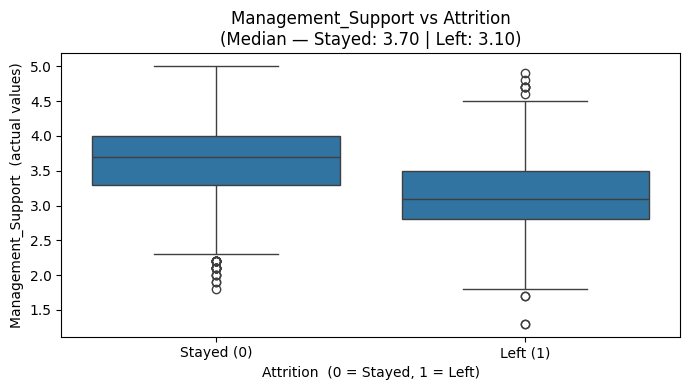

Interpretation: Y-axis = actual Management_Support values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


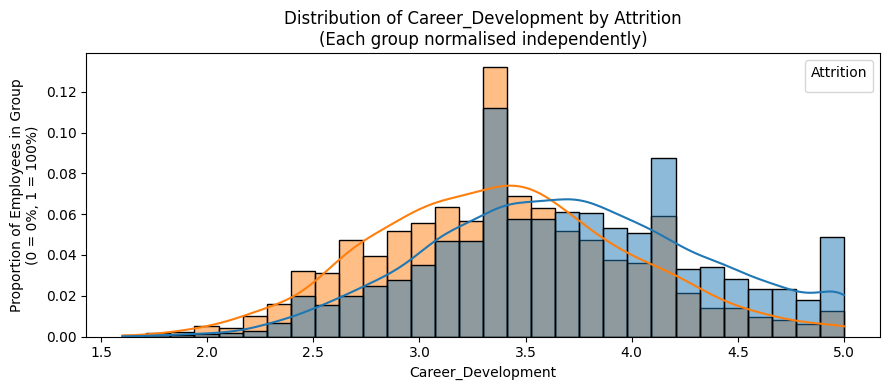

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Career_Development bin. Peaks at different x-positions signal that Career_Development differs between leavers and stayers.


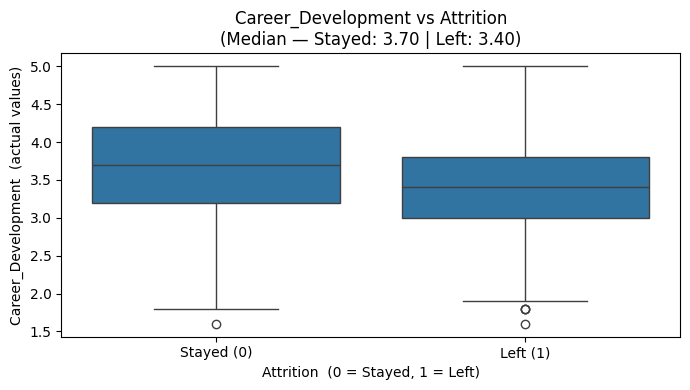

Interpretation: Y-axis = actual Career_Development values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


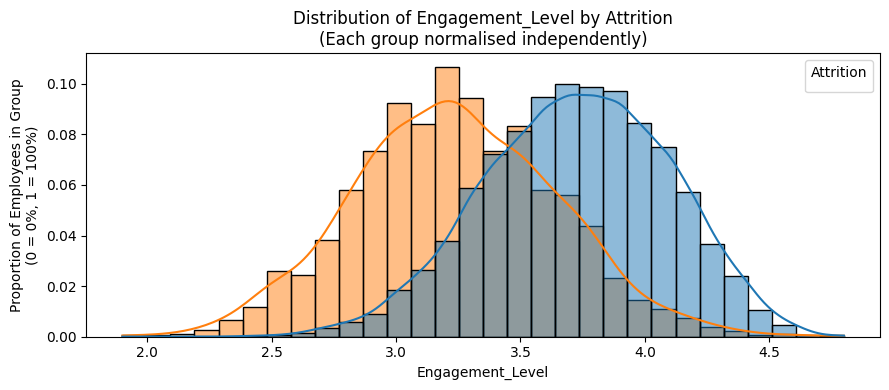

Interpretation: Y-axis = fraction of employees within each attrition group that fall in each Engagement_Level bin. Peaks at different x-positions signal that Engagement_Level differs between leavers and stayers.


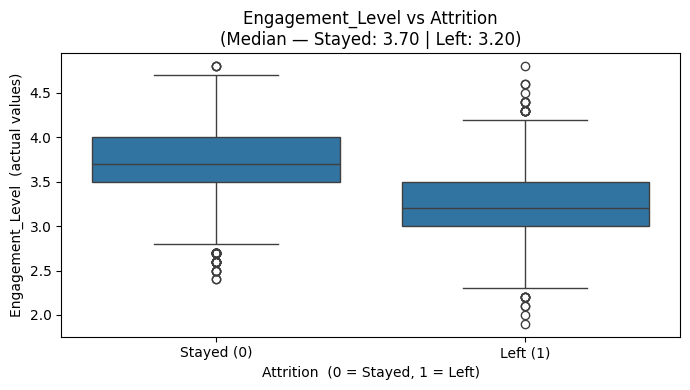

Interpretation: Y-axis = actual Engagement_Level values. The box spans the 25th–75th percentile; the line is the median. A clear median shift between groups indicates a meaningful signal.


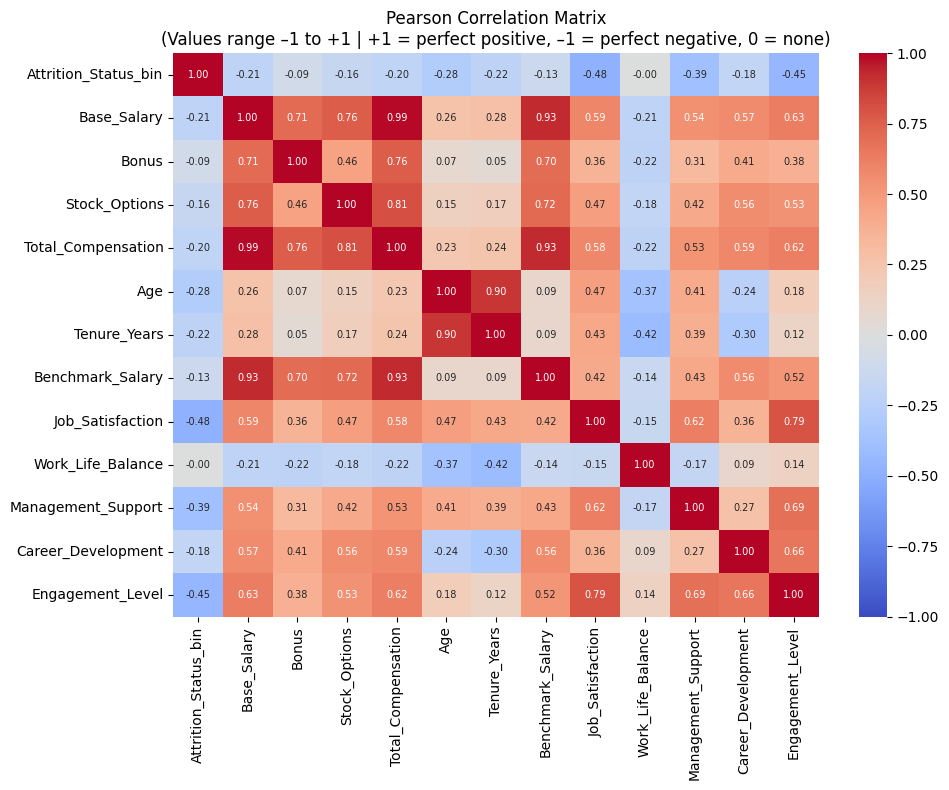

,Pearson r with Attrition
Job_Satisfaction,-0.483375
Engagement_Level,-0.445566
Management_Support,-0.387117
Age,-0.275099
Tenure_Years,-0.215117
Base_Salary,-0.206843
Total_Compensation,-0.197388
Career_Development,-0.184837
Stock_Options,-0.162860
Benchmark_Salary,-0.126664


Interpretation: Each cell = Pearson r between two features. The first row/column shows linear association with attrition. r > 0 means higher values → more attrition; r < 0 means the opposite. Values near 0 suggest no linear relationship.


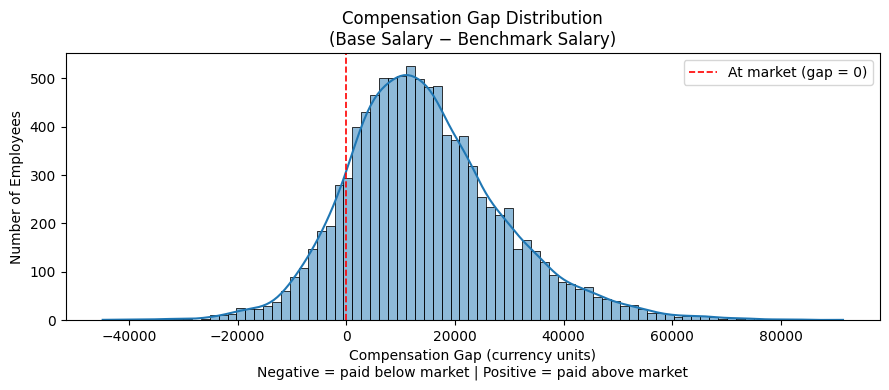

Interpretation: Y-axis = raw employee count. Red line = market parity. 13.3% of employees are paid below their benchmark — a potential retention risk pool.


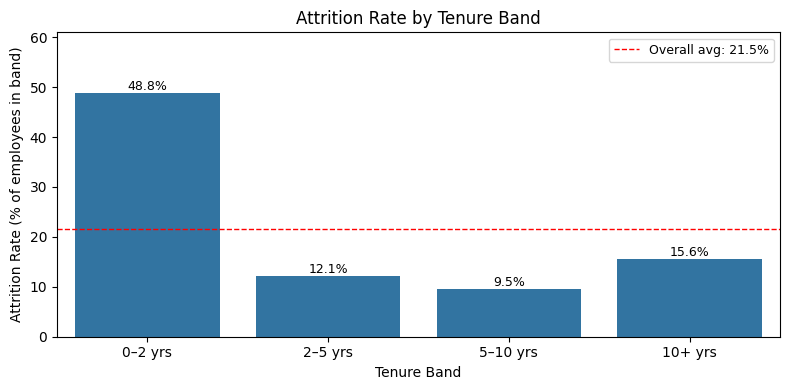

Interpretation: Y-axis = % of employees in each tenure band who left. Red dashed line = overall average. Bands above the line are higher-risk cohorts.


,feature,test,p_value,significant
1,Department,Chi-Square,0.000000,✅ Yes
2,Role,Chi-Square,0.000000,✅ Yes
3,Employment_Type,Chi-Square,0.000000,✅ Yes
4,Education_Level,Chi-Square,0.000000,✅ Yes
7,Location,Chi-Square,0.000000,✅ Yes
6,Work_Location,Chi-Square,0.000000,✅ Yes
10,Base_Salary,Point-Biserial,0.000000,✅ Yes
9,Feedback_Comments,Chi-Square,0.000000,✅ Yes
14,Age,Point-Biserial,0.000000,✅ Yes
13,Total_Compensation,Point-Biserial,0.000000,✅ Yes


Interpretation: p-value < 0.05 means the feature has a statistically significant association with attrition (marked ✅). Chi-Square is used for categorical features; Point-Biserial for numerical ones.


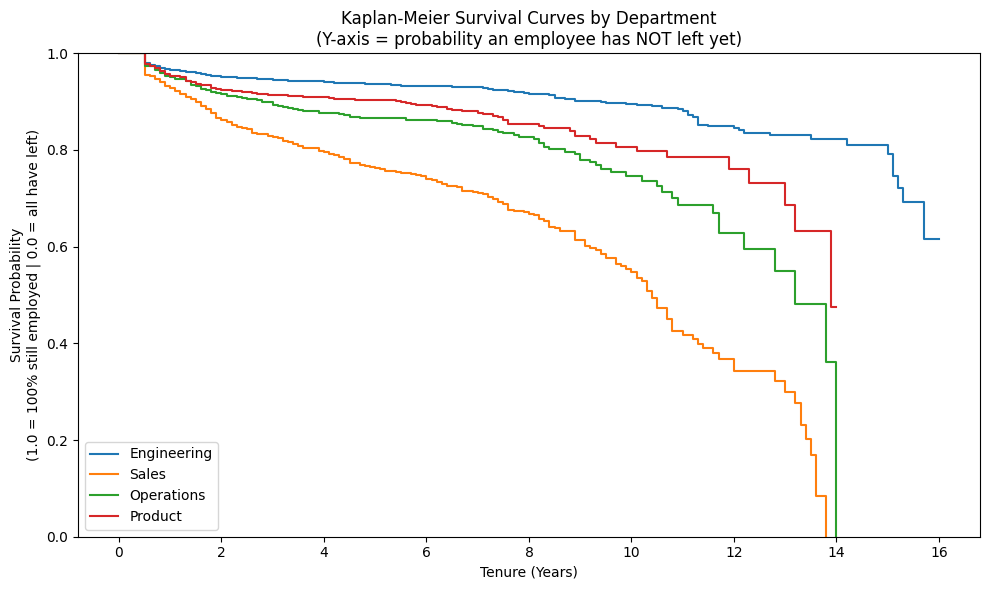

Interpretation: Y-axis = estimated probability that an employee is still with the company at a given tenure. A steeper drop means faster attrition in that department. Curves that separate early show tenure-specific risk differences.


In [23]:
target_bin = TARGET_COL + '_bin'
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_bin]
cat_cols = [c for c in df.select_dtypes(include=['object', 'category', 'string']).columns if c not in [TARGET_COL, 'Attrition_Date']]

# ─── 1. Attrition Base Rate ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[target_bin].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0],
    labels=['No Attrition', 'Attrition']
)
axes[0].set_title('Attrition Base Rate (%)\n(Share of total employees)')
axes[0].set_ylabel('')

sns.countplot(x=target_bin, data=df, ax=axes[1])
axes[1].set_title('Attrition Base Rate\n(Absolute employee count)')
axes[1].set_xlabel('Attrition  (0 = Stayed, 1 = Left)')
axes[1].set_ylabel('Number of Employees')
axes[1].bar_label(axes[1].containers[0], fmt='%d')   # show exact counts on bars

plt.tight_layout()
plt.show()
print('Interpretation: Pie shows % share; bar shows raw headcount. '
      'A large imbalance between the two bars means the model will need '
      'class-weighting or resampling.')


# ─── 2. Attrition Rate by Categorical Columns ─────────────────────────────────
for c in cat_cols:
    if df[c].nunique(dropna=True) <= 30:
        # mean() of a 0/1 column = proportion; multiply ×100 → percentage
        risk = (df.groupby(c)[target_bin].mean() * 100).sort_values(ascending=False)

        fig, ax = plt.subplots(figsize=(10, 4))
        bars = sns.barplot(x=risk.index, y=risk.values, ax=ax)
        ax.set_title(f'Attrition Rate by {c}')
        ax.set_xlabel(c)
        ax.set_ylabel('Attrition Rate (% of employees in category)')
        ax.set_ylim(0, min(risk.values.max() * 1.25, 100))  # headroom, cap at 100
        ax.axhline(risk.mean(), color='red', linestyle='--', linewidth=1,
                   label=f'Overall avg: {risk.mean():.1f}%')
        ax.legend(fontsize=9)
        # annotate each bar with its %
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=8)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        top3 = risk.head(3).round(1).to_dict()
        print(f'Interpretation: Y-axis = % of employees in each {c} category who left. '
              f'Red dashed line = overall average. Top 3 highest-risk: {top3}')


# ─── 3. Numerical Distributions split by Attrition ────────────────────────────
for c in num_cols:
    # -- Histogram: stat='probability' → y = fraction of group in each bin (0–1)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(
        data=df, x=c, hue=target_bin,
        kde=True, bins=30,
        stat='probability',      # ← changed from 'density'
        common_norm=False,        # each group sums to 1 independently
        ax=ax
    )
    ax.set_title(f'Distribution of {c} by Attrition\n'
                 '(Each group normalised independently)')
    ax.set_xlabel(c)
    ax.set_ylabel('Proportion of Employees in Group\n(0 = 0%, 1 = 100%)')
    # rename legend labels for clarity
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ['Stayed (0)', 'Left (1)'], title='Attrition')
    plt.tight_layout()
    plt.show()
    print(f'Interpretation: Y-axis = fraction of employees within each attrition group '
          f'that fall in each {c} bin. Peaks at different x-positions signal that '
          f'{c} differs between leavers and stayers.')

    # -- Boxplot: y = raw feature values
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(x=target_bin, y=c, data=df, ax=ax)
    medians = df.groupby(target_bin)[c].median()
    ax.set_title(f'{c} vs Attrition\n'
                 f'(Median — Stayed: {medians.get(0, "N/A"):.2f} | '
                 f'Left: {medians.get(1, "N/A"):.2f})')
    ax.set_xlabel('Attrition  (0 = Stayed, 1 = Left)')
    ax.set_ylabel(f'{c}  (actual values)')
    plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'])
    plt.tight_layout()
    plt.show()
    print(f'Interpretation: Y-axis = actual {c} values. '
          f'The box spans the 25th–75th percentile; the line is the median. '
          f'A clear median shift between groups indicates a meaningful signal.')


# ─── 4. Correlation Heatmap ────────────────────────────────────────────────────
corr_cols = [target_bin] + num_cols
corr_df = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, ax=ax)
ax.set_title('Pearson Correlation Matrix\n'
             '(Values range –1 to +1 | +1 = perfect positive, –1 = perfect negative, 0 = none)')
plt.tight_layout()
plt.show()

target_corr = corr_df[target_bin].drop(target_bin).sort_values(key=lambda s: s.abs(), ascending=False)
display(target_corr.head(15).to_frame('Pearson r with Attrition'))
print('Interpretation: Each cell = Pearson r between two features. '
      'The first row/column shows linear association with attrition. '
      'r > 0 means higher values → more attrition; r < 0 means the opposite. '
      'Values near 0 suggest no linear relationship.')


# ─── 5. Compensation Gap ──────────────────────────────────────────────────────
if {'Base_Salary', 'Benchmark_Salary'}.issubset(df.columns):
    df['compensation_gap'] = df['Base_Salary'] - df['Benchmark_Salary']

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(df['compensation_gap'], kde=True, stat='count', ax=ax)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='At market (gap = 0)')
    ax.set_title('Compensation Gap Distribution\n(Base Salary − Benchmark Salary)')
    ax.set_xlabel('Compensation Gap (currency units)\n'
                  'Negative = paid below market | Positive = paid above market')
    ax.set_ylabel('Number of Employees')
    ax.legend()
    plt.tight_layout()
    plt.show()
    pct_below = (df['compensation_gap'] < 0).mean() * 100
    print(f'Interpretation: Y-axis = raw employee count. '
          f'Red line = market parity. {pct_below:.1f}% of employees are paid '
          f'below their benchmark — a potential retention risk pool.')
else:
    print('Skipped compensation gap plot: required salary/benchmark columns not found.')


# ─── 6. Attrition Rate by Tenure Band ─────────────────────────────────────────
tenure_col = next((c for c in df.columns if 'tenure' in c.lower() and pd.api.types.is_numeric_dtype(df[c])), None)
if tenure_col:
    bins   = [0, 2, 5, 10, np.inf]
    labels = ['0–2 yrs', '2–5 yrs', '5–10 yrs', '10+ yrs']
    df['tenure_band'] = pd.cut(df[tenure_col], bins=bins, labels=labels, right=False)
    t_rate = (df.groupby('tenure_band')[target_bin].mean() * 100).reindex(labels)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = sns.barplot(x=t_rate.index.astype(str), y=t_rate.values, ax=ax)
    ax.set_title('Attrition Rate by Tenure Band')
    ax.set_xlabel('Tenure Band')
    ax.set_ylabel('Attrition Rate (% of employees in band)')
    ax.set_ylim(0, min(t_rate.max() * 1.25, 100))
    ax.axhline(t_rate.mean(), color='red', linestyle='--', linewidth=1,
               label=f'Overall avg: {t_rate.mean():.1f}%')
    ax.legend(fontsize=9)
    for p in ax.patches:
        if not np.isnan(p.get_height()):
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
    print('Interpretation: Y-axis = % of employees in each tenure band who left. '
          'Red dashed line = overall average. Bands above the line are higher-risk cohorts.')
else:
    print('Skipped tenure analysis: no tenure numeric column found.')


# ─── 7. Statistical Significance Tests ────────────────────────────────────────
stats_rows = []
for c in cat_cols:
    if 1 < df[c].nunique(dropna=True) <= 50:
        cont = pd.crosstab(df[c], df[target_bin])
        if cont.shape[0] > 1 and cont.shape[1] == 2:
            chi2, p, _, _ = chi2_contingency(cont)
            stats_rows.append({'feature': c, 'test': 'Chi-Square', 'p_value': round(p, 6)})

for c in num_cols:
    s = df[[c, target_bin]].dropna()
    if s[c].nunique() > 1:
        _, p = pointbiserialr(s[target_bin], s[c])
        stats_rows.append({'feature': c, 'test': 'Point-Biserial', 'p_value': round(p, 6)})

stats_df = (pd.DataFrame(stats_rows)
              .sort_values('p_value')
              .assign(significant=lambda d: d['p_value'].lt(0.05).map({True: '✅ Yes', False: '❌ No'})))
display(stats_df.head(20))
print('Interpretation: p-value < 0.05 means the feature has a statistically significant '
      'association with attrition (marked ✅). Chi-Square is used for categorical features; '
      'Point-Biserial for numerical ones.')


# ─── 8. Kaplan-Meier Survival Curves ──────────────────────────────────────────
dept_col = 'Department' if 'Department' in df.columns else None
if tenure_col and dept_col and KaplanMeierFitter is not None:
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(10, 6))
    top_groups = df[dept_col].value_counts().head(4).index
    for g in top_groups:
        sub = df[df[dept_col] == g]
        kmf.fit(durations=sub[tenure_col], event_observed=sub[target_bin], label=str(g))
        kmf.plot_survival_function(ci_show=False, ax=ax)
    ax.set_title('Kaplan-Meier Survival Curves by Department\n'
                 '(Y-axis = probability an employee has NOT left yet)')
    ax.set_xlabel('Tenure (Years)')
    ax.set_ylabel('Survival Probability\n(1.0 = 100% still employed | 0.0 = all have left)')
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
    print('Interpretation: Y-axis = estimated probability that an employee is still '
          'with the company at a given tenure. A steeper drop means faster attrition '
          'in that department. Curves that separate early show tenure-specific risk differences.')
elif KaplanMeierFitter is None:
    print('Skipped survival analysis: lifelines is not available in this environment.')
else:
    print('Skipped survival analysis: required tenure/department columns unavailable.')

## 3. NLP - Sentiment Analysis on Open-Text Feedback

This section creates NLP features from employee comments using a transformer sentiment model.
It also performs topic modeling and merges sentiment signals back into the unified modeling dataset.

In [24]:
import re

def clean_text(text: str) -> str:
    """Normalize free text for downstream NLP.

    Args:
        text: Raw text string.

    Returns:
        Cleaned text string.
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_sentiment_pipeline() -> Any:
    """Load primary transformer sentiment model with fallback.

    Returns:
        HuggingFace pipeline object.

    Raises:
        RuntimeError: If both primary and fallback models fail.
    """
    if pipeline is None:
        raise RuntimeError('transformers is not available in this environment.')

    primary = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
    fallback = 'distilbert-base-uncased-finetuned-sst-2-english'
    try:
        print('Loading primary sentiment model:', primary)
        return pipeline('sentiment-analysis', model=primary, tokenizer=primary, truncation=True, max_length=512)
    except Exception as e1:
        print('Primary model failed:', e1)
        try:
            print('Loading fallback sentiment model:', fallback)
            return pipeline('sentiment-analysis', model=fallback, tokenizer=fallback, truncation=True, max_length=512)
        except Exception as e2:
            raise RuntimeError(f'Both sentiment models failed. Primary: {e1}; Fallback: {e2}') from e2

def map_sentiment_to_score(label: str, score: float) -> Tuple[str, float]:
    """Map model output labels to unified label and signed score.

    Args:
        label: Raw model label.
        score: Confidence score from model.

    Returns:
        Tuple of normalized label and score in [-1, 1].
    """
    l = str(label).upper()
    if 'NEG' in l or l == 'LABEL_0':
        return 'Negative', -float(score)
    if 'NEU' in l:
        return 'Neutral', 0.0
    if 'POS' in l or l == 'LABEL_1':
        return 'Positive', float(score)
    return 'Neutral', 0.0

if TEXT_COL is None:
    print('No open-text column detected. Skipping Section 3 with justification.')
    nlp_df = pd.DataFrame({JOIN_KEY: df[JOIN_KEY]})
else:
    nlp_df = df[[JOIN_KEY, TEXT_COL, target_bin]].dropna(subset=[TEXT_COL]).copy()
    nlp_df['clean_text'] = nlp_df[TEXT_COL].astype(str).map(clean_text)
    print('Sample cleaned text:')
    display(nlp_df[['clean_text']].head())

    try:
        sent_pipe = get_sentiment_pipeline()
    except Exception as e:
        print('Sentiment models unavailable. Skipping NLP sentiment section:', e)
        sent_pipe = None

    if sent_pipe is not None:
        preds = []
        texts = nlp_df['clean_text'].tolist()
        for i in tqdm(range(0, len(texts), 32), desc='Sentiment batching'):
            batch = texts[i:i+32]
            try:
                out = sent_pipe(batch, truncation=True, max_length=512)
            except Exception:
                out = [{'label': 'NEUTRAL', 'score': 0.0}] * len(batch)
            preds.extend(out)

        mapped = [map_sentiment_to_score(p['label'], p['score']) for p in preds]
        nlp_df['sentiment_label'] = [m[0] for m in mapped]
        nlp_df['sentiment_score'] = [m[1] for m in mapped]

        # Sentiment EDA
        plt.figure(figsize=(8, 4))
        sns.countplot(x='sentiment_label', data=nlp_df, order=['Negative', 'Neutral', 'Positive'])
        plt.title('Sentiment Label Distribution')
        plt.xlabel('Sentiment Label')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
        print('Interpretation: Sentiment mix indicates prevailing tone in employee comments.')

        plt.figure(figsize=(9, 4))
        sns.kdeplot(data=nlp_df, x='sentiment_score', hue=target_bin, common_norm=False, fill=True, alpha=0.2)
        plt.title('Sentiment Score Distribution by Attrition')
        plt.xlabel('Sentiment Score')
        plt.ylabel('Density')
        plt.tight_layout()
        plt.show()
        print('Interpretation: Separation between class curves suggests sentiment carries attrition signal.')

        plt.figure(figsize=(7, 4))
        sns.boxplot(data=nlp_df, x=target_bin, y='sentiment_score')
        plt.title('Sentiment Score vs Attrition')
        plt.xlabel('Attrition')
        plt.ylabel('Sentiment Score')
        plt.tight_layout()
        plt.show()

        corr_val, corr_p = pointbiserialr(nlp_df[target_bin], nlp_df['sentiment_score'])
        print(f'Point-biserial corr(sentiment, attrition): {corr_val:.4f}, p={corr_p:.4g}')
        mean_left = nlp_df.loc[nlp_df[target_bin] == 1, 'sentiment_score'].mean()
        mean_stay = nlp_df.loc[nlp_df[target_bin] == 0, 'sentiment_score'].mean()
        relation = 'lower' if mean_left < mean_stay else 'higher'
        print(f'Employees who left had {relation} average sentiment scores.')

        # Topic modeling
        texts_tm = nlp_df['clean_text'].tolist()
        topic_model = None
        bertopic_mod = optional_import('bertopic')
        BERTopic = getattr(bertopic_mod, 'BERTopic', None)
        try:
            if BERTopic is None:
                raise RuntimeError('bertopic not installed')
            topic_model = BERTopic(verbose=False, calculate_probabilities=False, min_topic_size=max(20, len(texts_tm)//200))
            topics, _ = topic_model.fit_transform(texts_tm)
            nlp_df['topic_id'] = topics
            print('BERTopic fitted successfully.')
            top_words = topic_model.get_topics()
            preview_rows = []
            for t_id, words in list(top_words.items())[:10]:
                if t_id == -1:
                    continue
                preview_rows.append({'topic_id': t_id, 'top_words': ', '.join([w for w, _ in words[:10]])})
            display(pd.DataFrame(preview_rows))

            plt.figure(figsize=(8, 4))
            nlp_df['topic_id'].value_counts().head(10).plot(kind='bar')
            plt.title('Topic Distribution (Top 10)')
            plt.xlabel('Topic ID')
            plt.ylabel('Count')
            plt.tight_layout()
            plt.show()
            print('Interpretation: Dominant topics represent recurring employee themes that can guide interventions.')
        except Exception as e:
            print('BERTopic unavailable or failed, falling back to LDA:', e)
            from sklearn.feature_extraction.text import CountVectorizer
            from sklearn.decomposition import LatentDirichletAllocation

            vec = CountVectorizer(max_features=1000, stop_words='english')
            X_tm = vec.fit_transform(texts_tm)
            n_topics = 5
            lda = LatentDirichletAllocation(n_components=n_topics, random_state=RANDOM_STATE)
            topic_probs = lda.fit_transform(X_tm)
            nlp_df['topic_id'] = topic_probs.argmax(axis=1)

            vocab = np.array(vec.get_feature_names_out())
            rows = []
            for i, comp in enumerate(lda.components_):
                top_idx = np.argsort(comp)[-10:][::-1]
                rows.append({'topic_id': i, 'top_words': ', '.join(vocab[top_idx])})
            display(pd.DataFrame(rows))

            plt.figure(figsize=(8, 4))
            nlp_df['topic_id'].value_counts().sort_index().plot(kind='bar')
            plt.title('LDA Topic Distribution')
            plt.xlabel('Topic ID')
            plt.ylabel('Count')
            plt.tight_layout()
            plt.show()
            print('Interpretation: Topic prevalence reflects common feedback clusters in employee comments.')

        sentiment_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
        nlp_df['sentiment_label_encoded'] = nlp_df['sentiment_label'].map(sentiment_map).fillna(1).astype(int)

        # Merge NLP features back
        merge_cols = [JOIN_KEY, 'sentiment_score', 'sentiment_label', 'sentiment_label_encoded']
        if 'topic_id' in nlp_df.columns:
            merge_cols.append('topic_id')
        df = df.merge(nlp_df[merge_cols], on=JOIN_KEY, how='left')
        print('NLP features added: sentiment_score, sentiment_label_encoded' + (', topic_id' if 'topic_id' in nlp_df.columns else ''))
    else:
        print('NLP features were not added because sentiment pipeline could not be initialized.')

Sample cleaned text:


,clean_text
0,salary is decent but bonuses could be better
1,work is okay but growth opportunities are limited
2,very happy with my role learning a lot every day
3,workload is sometimes heavy but manageable
4,excellent team culture and flexible hours


Loading primary sentiment model: cardiffnlp/twitter-roberta-base-sentiment-latest


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 34616.70it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Sentiment batching:  33%|███▎      | 103/313 [02:08<04:22,  1.25s/it]


KeyboardInterrupt: 

## 4. Data Preprocessing & Feature Engineering

This section handles missing values, outliers, and feature engineering with strict leakage prevention.
It then performs encoding, stratified train/validation/test splitting, and class-imbalance treatment.

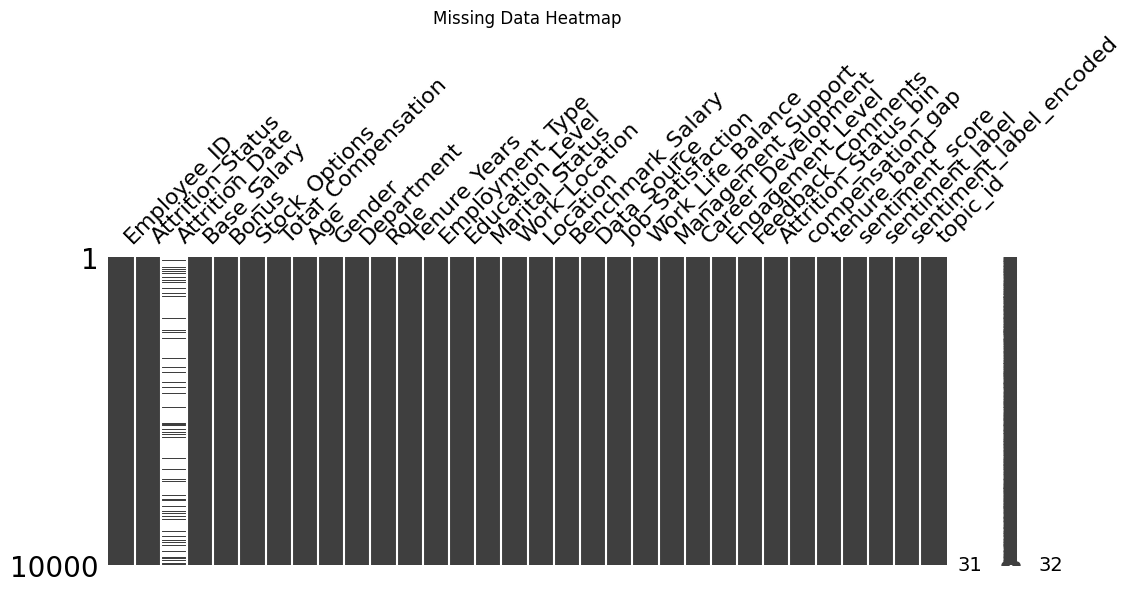

Imputation decisions:


,column,type,strategy
0,Attrition_Date,categorical,mode


,column,capped_low_count,capped_high_count
11,Engagement_Level,149,9
7,Job_Satisfaction,107,0
9,Management_Support,64,19
12,compensation_gap,38,216
8,Work_Life_Balance,13,19
10,Career_Development,11,0
2,Stock_Options,0,367
6,Benchmark_Salary,0,230
1,Bonus,0,180
3,Total_Compensation,0,149


Correlation with target for compa_ratio: -0.2475


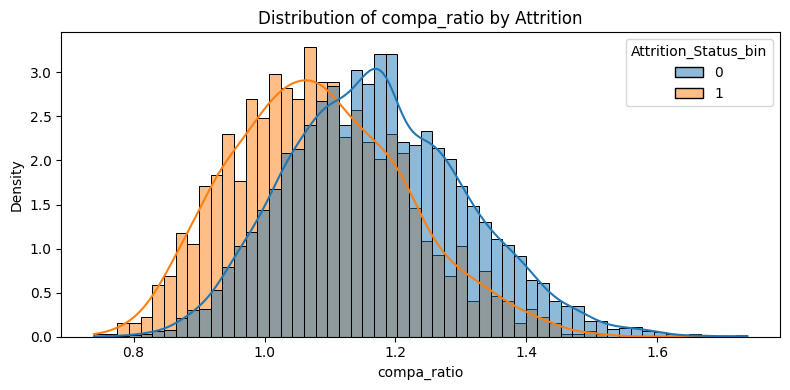

Interpretation: compa_ratio appears to carry incremental risk signal when distributions differ by attrition class.
Correlation with target for pre_model_risk_score: 0.2995


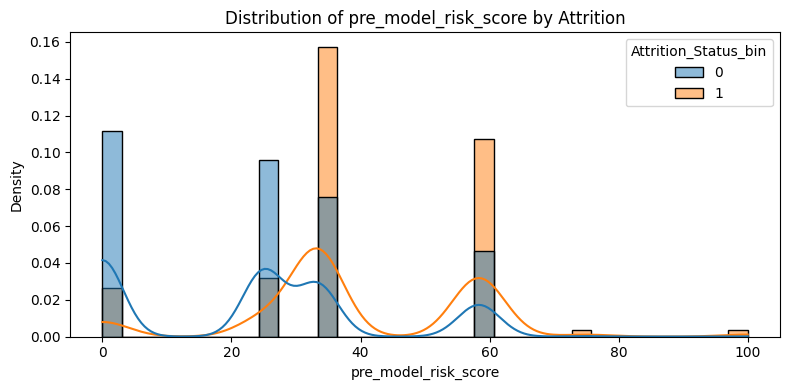

Interpretation: pre_model_risk_score appears to carry incremental risk signal when distributions differ by attrition class.
Class distribution before imbalance treatment:
Train: {0: 0.8191428571428572, 1: 0.18085714285714286}
Val  : {0: 0.8193333333333334, 1: 0.18066666666666667}
Test : {0: 0.8193333333333334, 1: 0.18066666666666667}

Class distribution after imbalance step (train):
{0: 0.5, 1: 0.5}


In [ ]:
def add_missing_flags_and_impute(data: pd.DataFrame, target: str) -> pd.DataFrame:
    """Impute missing values and add missingness indicators when null rate > 5%.

    Args:
        data: Input dataframe.
        target: Target binary column name.

    Returns:
        Processed dataframe with imputations and flags.
    """
    out = data.copy()
    if msno is not None:
        msno.matrix(out, figsize=(12, 4))
        plt.title('Missing Data Heatmap')
        plt.show()
    else:
        print('missingno is unavailable; skipping null heatmap plot.')

    null_rates = out.isna().mean()
    num_cols_local = [c for c in out.select_dtypes(include=[np.number]).columns if c != target]
    cat_cols_local = [c for c in out.select_dtypes(include=['object', 'category', 'string']).columns]

    decisions = []
    for c in num_cols_local:
        if null_rates[c] > 0.05:
            out[c + '_missing_flag'] = out[c].isna().astype(int)
        if out[c].isna().any():
            out[c] = out[c].fillna(out[c].median())
            decisions.append((c, 'numerical', 'median'))

    for c in cat_cols_local:
        if null_rates[c] > 0.05:
            out[c + '_missing_flag'] = out[c].isna().astype(int)
        if out[c].isna().any():
            mode_val = out[c].mode(dropna=True)
            fill_val = mode_val.iloc[0] if len(mode_val) else 'Unknown'
            out[c] = out[c].fillna(fill_val)
            decisions.append((c, 'categorical', 'mode'))

    if decisions:
        print('Imputation decisions:')
        display(pd.DataFrame(decisions, columns=['column', 'type', 'strategy']))
    else:
        print('No imputations were required.')

    return out

def cap_outliers_iqr(data: pd.DataFrame, target: str) -> pd.DataFrame:
    """Cap numeric outliers using IQR boundaries without dropping rows.

    Args:
        data: Input dataframe.
        target: Target binary column name.

    Returns:
        Dataframe with capped outliers.
    """
    out = data.copy()
    cols = [c for c in out.select_dtypes(include=[np.number]).columns if c != target]
    report = []

    for c in cols:
        s = out[c]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        before_low = int((s < low).sum())
        before_high = int((s > high).sum())
        out[c] = s.clip(lower=low, upper=high)
        report.append({'column': c, 'capped_low_count': before_low, 'capped_high_count': before_high})

    if report:
        display(pd.DataFrame(report).sort_values(['capped_low_count', 'capped_high_count'], ascending=False).head(20))
    return out

def engineer_features(data: pd.DataFrame, target: str) -> pd.DataFrame:
    """Create engineered features conditionally based on available source columns.

    Args:
        data: Input dataframe.
        target: Target binary column name.

    Returns:
        Dataframe with additional engineered features.
    """
    out = data.copy()

    # Compa-ratio
    if {'Base_Salary', 'Benchmark_Salary'}.issubset(out.columns):
        out['compa_ratio'] = out['Base_Salary'] / out['Benchmark_Salary'].replace(0, np.nan)
        out['high_comp_risk_flag'] = (out['compa_ratio'] < 0.85).astype(int)

    # Tenure band
    tenure_col_local = next((c for c in out.columns if 'tenure' in c.lower() and pd.api.types.is_numeric_dtype(out[c])), None)
    if tenure_col_local:
        out['tenure_band_fe'] = pd.cut(out[tenure_col_local], [0, 2, 5, 10, np.inf], labels=['Early', 'Growth', 'Mature', 'Senior'], right=False)

    # Promotion velocity gap (if promotion column exists)
    promo_col = next((c for c in out.columns if 'promotion' in c.lower() and pd.api.types.is_numeric_dtype(out[c])), None)
    role_col = 'Role' if 'Role' in out.columns else None
    if promo_col and role_col:
        role_mean = out.groupby(role_col)[promo_col].transform('mean')
        out['promotion_velocity_gap'] = out[promo_col] - role_mean
        out['promotion_gap_flag'] = (out['promotion_velocity_gap'] > out['promotion_velocity_gap'].median()).astype(int)

    # Composite pre-model risk score using available flags
    flags = []
    if 'high_comp_risk_flag' in out.columns:
        flags.append('high_comp_risk_flag')
    if 'Job_Satisfaction' in out.columns:
        out['low_satisfaction_flag'] = (out['Job_Satisfaction'] < out['Job_Satisfaction'].median()).astype(int)
        flags.append('low_satisfaction_flag')
    if 'Work_Life_Balance' in out.columns:
        out['low_wlb_flag'] = (out['Work_Life_Balance'] < out['Work_Life_Balance'].median()).astype(int)
        flags.append('low_wlb_flag')
    if 'promotion_gap_flag' in out.columns:
        flags.append('promotion_gap_flag')

    if flags:
        weights = np.linspace(1.0, 0.6, len(flags))
        raw_score = np.zeros(len(out))
        for w, f in zip(weights, flags):
            raw_score += w * out[f].values
        raw_min, raw_max = raw_score.min(), raw_score.max()
        out['pre_model_risk_score'] = 100 * (raw_score - raw_min) / (raw_max - raw_min + 1e-9)

    # Correlations and plots for engineered numeric features
    engineered_num = [c for c in ['compa_ratio', 'promotion_velocity_gap', 'pre_model_risk_score'] if c in out.columns]
    for c in engineered_num:
        try:
            corr = out[[c, target]].corr().iloc[0, 1]
            print(f'Correlation with target for {c}: {corr:.4f}')
        except Exception:
            pass
        plt.figure(figsize=(8, 4))
        sns.histplot(data=out, x=c, hue=target, kde=True, stat='density', common_norm=False)
        plt.title(f'Distribution of {c} by Attrition')
        plt.xlabel(c)
        plt.ylabel('Density')
        plt.tight_layout()
        plt.show()
        print(f'Interpretation: {c} appears to carry incremental risk signal when distributions differ by attrition class.')

    return out


df_prep = add_missing_flags_and_impute(df, target_bin)
df_prep = cap_outliers_iqr(df_prep, target_bin)
df_prep = engineer_features(df_prep, target_bin)

# Encoding
model_df = df_prep.copy()

if target_bin not in model_df.columns:
    raise RuntimeError('Binary target column missing after preprocessing.')

feature_cols = [c for c in model_df.columns if c not in [TARGET_COL, target_bin, 'Attrition_Date', TEXT_COL]]
X_raw = model_df[feature_cols].copy()
y = model_df[target_bin].astype(int).copy()

# One-hot encoding for nominal variables
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# Stratified splits: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, test_size=(TEST_SIZE + VAL_SIZE), random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(TEST_SIZE / (TEST_SIZE + VAL_SIZE)), random_state=RANDOM_STATE, stratify=y_temp)

print('Class distribution before imbalance treatment:')
print('Train:', y_train.value_counts(normalize=True).to_dict())
print('Val  :', y_val.value_counts(normalize=True).to_dict())
print('Test :', y_test.value_counts(normalize=True).to_dict())

# SMOTE on train only
if SMOTE is None:
    print('SMOTE is unavailable; continuing with original class distribution in training set.')
    X_train_sm, y_train_sm = X_train, y_train
else:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nClass distribution after imbalance step (train):')
print(pd.Series(y_train_sm).value_counts(normalize=True).to_dict())

## 5. Model Training & Hyperparameter Tuning

This section trains and tunes three models: XGBoost, Random Forest, and the reference model family (CatBoost).
Each training routine is modular, Optuna-driven, and reports best validation ROC-AUC.

In [ ]:
def optimize_xgboost(X_tr, y_tr, X_v, y_v, n_trials: int = 50) -> Tuple[Any, Dict[str, Any], Any]:
    """Tune and train XGBoost using Optuna.

    Args:
        X_tr: Training features.
        y_tr: Training labels.
        X_v: Validation features.
        y_v: Validation labels.
        n_trials: Number of Optuna trials.

    Returns:
        Best model, best params, and study object.
    """
    if optuna is None or XGBClassifier is None:
        raise RuntimeError('XGBoost/Optuna dependency unavailable.')

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    scale_pos_weight = max(1.0, neg / max(pos, 1))

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_float('min_child_weight', 1, 20),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_STATE,
            'scale_pos_weight': scale_pos_weight,
            'eval_metric': 'auc',
            'tree_method': 'hist'
        }
        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        pred = model.predict_proba(X_v)[:, 1]
        return roc_auc_score(y_v, pred)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_params = study.best_params
    best_params.update({'random_state': RANDOM_STATE, 'scale_pos_weight': scale_pos_weight, 'eval_metric': 'auc', 'tree_method': 'hist'})
    best_model = XGBClassifier(**best_params)
    best_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    return best_model, best_params, study

def optimize_random_forest(X_tr, y_tr, X_v, y_v, n_trials: int = 30) -> Tuple[Any, Dict[str, Any], Any]:
    """Tune and train RandomForest using Optuna.

    Args:
        X_tr: Training features.
        y_tr: Training labels.
        X_v: Validation features.
        y_v: Validation labels.
        n_trials: Number of trials.

    Returns:
        Best model, params, and study.
    """
    if optuna is None:
        raise RuntimeError('Optuna dependency unavailable.')

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 900),
            'max_depth': trial.suggest_int('max_depth', 4, 24),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'class_weight': 'balanced',
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)
        pred = model.predict_proba(X_v)[:, 1]
        return roc_auc_score(y_v, pred)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_params = study.best_params
    best_params.update({'class_weight': 'balanced', 'random_state': RANDOM_STATE, 'n_jobs': -1})
    best_model = RandomForestClassifier(**best_params)
    best_model.fit(X_tr, y_tr)
    return best_model, best_params, study

def optimize_catboost(X_tr, y_tr, X_v, y_v, n_trials: int = 30) -> Tuple[Any, Dict[str, Any], Any]:
    """Tune and train CatBoost (reference model family) using Optuna.

    Args:
        X_tr: Training features.
        y_tr: Training labels.
        X_v: Validation features.
        y_v: Validation labels.
        n_trials: Number of trials.

    Returns:
        Best model, params, and study.
    """
    if optuna is None or CatBoostClassifier is None:
        raise RuntimeError('CatBoost/Optuna dependency unavailable.')

    def objective(trial):
        params = {
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 15.0),
            'iterations': trial.suggest_int('iterations', 150, 700),
            'random_seed': RANDOM_STATE,
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'verbose': False
        }
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_v, y_v), use_best_model=True, verbose=False)
        pred = model.predict_proba(X_v)[:, 1]
        return roc_auc_score(y_v, pred)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_params = study.best_params
    best_params.update({'random_seed': RANDOM_STATE, 'loss_function': 'Logloss', 'eval_metric': 'AUC', 'verbose': False})
    best_model = CatBoostClassifier(**best_params)
    best_model.fit(X_tr, y_tr, eval_set=(X_v, y_v), use_best_model=True, verbose=False)
    return best_model, best_params, study

models = {}
studies = {}
best_params_all = {}

xgb_model, xgb_params, xgb_study = optimize_xgboost(X_train_sm, y_train_sm, X_val, y_val, n_trials=50)
models['XGBoost'] = xgb_model
studies['XGBoost'] = xgb_study
best_params_all['XGBoost'] = xgb_params
print('XGBoost best params:', xgb_params)
print('XGBoost best val ROC-AUC:', xgb_study.best_value)

rf_model, rf_params, rf_study = optimize_random_forest(X_train_sm, y_train_sm, X_val, y_val, n_trials=30)
models['RandomForest'] = rf_model
studies['RandomForest'] = rf_study
best_params_all['RandomForest'] = rf_params
print('RandomForest best params:', rf_params)
print('RandomForest best val ROC-AUC:', rf_study.best_value)

cb_model, cb_params, cb_study = optimize_catboost(X_train_sm, y_train_sm, X_val, y_val, n_trials=30)
models['CatBoost'] = cb_model
studies['CatBoost'] = cb_study
best_params_all['CatBoost'] = cb_params
print('CatBoost best params:', cb_params)
print('CatBoost best val ROC-AUC:', cb_study.best_value)

for name, study in studies.items():
    try:
        optuna.visualization.matplotlib.plot_optimization_history(study)
        plt.title(f'Optuna Optimization History - {name}')
        plt.show()
    except Exception:
        pass

for name, model in models.items():
    joblib.dump(model, OUTPUT_DIR / f'{name.lower()}_best_model.joblib')
print('Saved tuned model objects to outputs folder.')

[I 2026-04-09 12:43:35,948] A new study created in memory with name: no-name-205d7c18-535b-4076-90ef-89ceb0e2046a
Best trial: 0. Best value: 1:   2%|▏         | 1/50 [00:30<24:41, 30.24s/it]

[I 2026-04-09 12:44:06,190] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 287, 'max_depth': 10, 'learning_rate': 0.0483437145318464, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 3.96389588638785, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 1.0.


Best trial: 0. Best value: 1:   4%|▍         | 2/50 [01:39<42:27, 53.08s/it]

[I 2026-04-09 12:45:15,250] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 401, 'max_depth': 8, 'learning_rate': 0.0011152328125494347, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 5.034443102887247, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 0 with value: 1.0.


Best trial: 0. Best value: 1:   6%|▌         | 3/50 [02:20<37:14, 47.54s/it]

[I 2026-04-09 12:45:56,200] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 252, 'max_depth': 7, 'learning_rate': 0.009860942908083906, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578889518, 'min_child_weight': 3.6503833523887947, 'reg_alpha': 4.258943089524393e-06, 'reg_lambda': 1.9826980964985924e-05}. Best is trial 0 with value: 1.0.


Best trial: 0. Best value: 1:   6%|▌         | 3/50 [02:44<43:02, 54.95s/it]


[W 2026-04-09 12:46:20,647] Trial 3 failed with parameters: {'n_estimators': 328, 'max_depth': 9, 'learning_rate': 0.0028804169778805498, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_weight': 1.8825578416799567, 'reg_alpha': 0.0029369981104377003, 'reg_lambda': 3.425445902633376e-07} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\MQFJ5881\OneDrive - orange.com\Bureau\Hackathon\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\MQFJ5881\AppData\Local\Temp\ipykernel_22940\860387471.py", line 37, in objective
    model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MQFJ5881\OneDrive - orange.com\Bureau\Hackathon\.venv\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
  File "c:\Users\MQFJ5881\OneDrive

KeyboardInterrupt: 

## 6. Model Evaluation & Comparative Analysis

This section evaluates all tuned models on the held-out test set with threshold optimization.
It compares ROC/PR performance, calibration, and business lift before selecting a final winner.

In [ ]:
def business_lift(y_true: np.ndarray, y_prob: np.ndarray, top_pct: float = 0.2) -> float:
    """Compute lift at top percentile against random baseline.

    Args:
        y_true: True binary labels.
        y_prob: Predicted probabilities.
        top_pct: Top fraction to target.

    Returns:
        Lift value.
    """
    n = len(y_true)
    k = max(1, int(n * top_pct))
    idx = np.argsort(-y_prob)[:k]
    rate_top = y_true[idx].mean()
    rate_all = y_true.mean()
    return float(rate_top / max(rate_all, 1e-9))

def find_best_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> Tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """Find threshold maximizing F1 on a given set.

    Args:
        y_true: True labels.
        y_prob: Predicted probabilities.

    Returns:
        Best threshold, best F1, precision array, recall array, threshold array.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-9)
    best_idx = int(np.argmax(f1s))
    return float(thresholds[best_idx]), float(f1s[best_idx]), precision, recall, thresholds

def evaluate_model(name: str, model: Any, X_v: pd.DataFrame, y_v: pd.Series, X_te: pd.DataFrame, y_te: pd.Series) -> Dict[str, Any]:
    """Evaluate one model with tuned threshold selection from validation set.

    Args:
        name: Model name.
        model: Trained model object.
        X_v: Validation features.
        y_v: Validation labels.
        X_te: Test features.
        y_te: Test labels.

    Returns:
        Metrics dictionary.
    """
    val_prob = model.predict_proba(X_v)[:, 1]
    thr, val_best_f1, p_arr, r_arr, thr_arr = find_best_threshold(y_v.values, val_prob)

    test_prob = model.predict_proba(X_te)[:, 1]
    test_pred = (test_prob >= thr).astype(int)

    roc_auc = roc_auc_score(y_te, test_prob)
    pr_precision, pr_recall, _ = precision_recall_curve(y_te, test_prob)
    pr_auc = auc(pr_recall, pr_precision)
    f1 = f1_score(y_te, test_pred)
    brier = brier_score_loss(y_te, test_prob)
    lift20 = business_lift(y_te.values, test_prob, top_pct=0.2)

    # Confusion matrix
    cm = confusion_matrix(y_te, test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    print(classification_report(y_te, test_pred))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, test_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC-AUC={roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR curve
    plt.figure(figsize=(6, 4))
    plt.plot(pr_recall, pr_precision, label=f'PR-AUC={pr_auc:.3f}')
    plt.title(f'Precision-Recall Curve - {name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Threshold diagnostic plots
    f1s = 2 * p_arr[:-1] * r_arr[:-1] / np.maximum(p_arr[:-1] + r_arr[:-1], 1e-9)
    plt.figure(figsize=(8, 4))
    plt.plot(thr_arr, f1s, label='F1 vs threshold')
    plt.axvline(thr, color='red', linestyle='--', label=f'best={thr:.3f}')
    plt.title(f'F1 vs Threshold - {name}')
    plt.xlabel('Threshold')
    plt.ylabel('F1')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(thr_arr, p_arr[:-1], label='Precision')
    plt.plot(thr_arr, r_arr[:-1], label='Recall')
    plt.axvline(thr, color='red', linestyle='--', label=f'best={thr:.3f}')
    plt.title(f'Precision/Recall vs Threshold - {name}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'model': name,
        'threshold': thr,
        'val_best_f1': val_best_f1,
        'test_roc_auc': roc_auc,
        'test_pr_auc': pr_auc,
        'test_f1': f1,
        'test_brier': brier,
        'lift_at_20pct': lift20
    }

evaluation_rows = []
for name, model in models.items():
    print(f'\nEvaluating model: {name}')
    row = evaluate_model(name, model, X_val, y_val, X_test, y_test)
    evaluation_rows.append(row)

evaluation_df = pd.DataFrame(evaluation_rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
display(evaluation_df.style.highlight_max(axis=0, subset=['test_roc_auc', 'test_pr_auc', 'test_f1', 'lift_at_20pct']).highlight_min(axis=0, subset=['test_brier']))

winner_row = evaluation_df.sort_values(['test_roc_auc', 'test_pr_auc', 'test_f1'], ascending=False).iloc[0]
WINNER_MODEL_NAME = winner_row['model']
WINNER_MODEL = models[WINNER_MODEL_NAME]
print(f'Winner model selected: {WINNER_MODEL_NAME}')
print('Justification based on ROC-AUC, PR-AUC, F1, and Brier score is shown in the comparison table above.')

## 7. Explainability - SHAP & LIME

This section explains the winning model globally and locally using SHAP and LIME.
It helps HR stakeholders understand both overall drivers and employee-specific risk reasons.

In [ ]:
# SHAP global and local explainability
explainer = shap.TreeExplainer(WINNER_MODEL)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_arr = shap_values[1]
else:
    shap_arr = shap_values

shap.summary_plot(shap_arr, X_test, max_display=20)
plt.show()
print('Interpretation: Beeswarm plot shows top global drivers and directionality of risk contributions.')

mean_abs_shap = np.abs(shap_arr).mean(axis=0)
driver_df = pd.DataFrame({'feature': X_test.columns, 'mean_abs_shap': mean_abs_shap})
driver_df = driver_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
display(driver_df.head(20))

shap.summary_plot(shap_arr, X_test, plot_type='bar', max_display=20)
plt.show()
print('Interpretation: Bar plot ranks features by average contribution magnitude to model predictions.')

top3 = driver_df['feature'].head(3).tolist()
for feat in top3:
    try:
        shap.dependence_plot(feat, shap_arr, X_test, interaction_index='auto')
        plt.show()
        print(f'Interpretation: Dependence plot for {feat} shows how risk changes with feature value and interactions.')
    except Exception as e:
        print(f'Skipped dependence plot for {feat}:', e)

# Select high/medium/low risk examples
test_probs = WINNER_MODEL.predict_proba(X_test)[:, 1]
sorted_idx = np.argsort(test_probs)
low_idx = sorted_idx[int(0.1 * len(sorted_idx))]
med_idx = sorted_idx[int(0.5 * len(sorted_idx))]
high_idx = sorted_idx[int(0.9 * len(sorted_idx))]
sample_indices = {'Low': low_idx, 'Medium': med_idx, 'High': high_idx}

for label, idx in sample_indices.items():
    shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_arr[idx], X_test.iloc[idx], show=True)
    top_contrib_idx = np.argsort(np.abs(shap_arr[idx]))[-3:][::-1]
    reasons = [(X_test.columns[i], X_test.iloc[idx, i], shap_arr[idx, i]) for i in top_contrib_idx]
    print(f'{label} risk employee explanation:')
    for feat, val, contrib in reasons:
        direction = 'increases' if contrib > 0 else 'decreases'
        print(f'  - {feat}={val} {direction} risk (SHAP={contrib:.4f})')

# LIME explanations for same 3 employees
lime_exp = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['No Attrition', 'Attrition'],
    mode='classification',
    random_state=RANDOM_STATE
)

for label, idx in sample_indices.items():
    exp = lime_exp.explain_instance(X_test.iloc[idx].values, WINNER_MODEL.predict_proba, num_features=10)
    print(f'\nLIME explanation for {label} risk employee:')
    for rule, weight in exp.as_list():
        print(f'  - {rule}: {weight:.4f}')
    print('Comparison note: Compare these local feature rules against SHAP waterfall contributions above.')

# PDP + ICE for top 3 features
from sklearn.inspection import PartialDependenceDisplay
for feat in top3:
    try:
        PartialDependenceDisplay.from_estimator(WINNER_MODEL, X_test, [feat], kind='both')
        plt.title(f'PDP + ICE for {feat}')
        plt.tight_layout()
        plt.show()
        print(f'Interpretation: PDP/ICE for {feat} shows average and individual risk trajectories as the feature changes.')
    except Exception as e:
        print(f'Skipped PDP/ICE for {feat}:', e)

## 8. Risk Scoring & Employee Segmentation

This section scores all employees with the winning model and assigns risk tiers.
It then builds behavioral personas with K-Means clustering on top SHAP drivers plus predicted attrition probability.

In [ ]:
# Score all employees
all_X = X_encoded.copy()
all_probs = WINNER_MODEL.predict_proba(all_X)[:, 1]
scored_df = model_df[[JOIN_KEY]].copy()
scored_df['attrition_probability'] = all_probs

def assign_risk_tier(p: float) -> str:
    """Assign categorical risk tier from probability.

    Args:
        p: Attrition probability.

    Returns:
        Risk tier label.
    """
    if p > 0.70:
        return 'High'
    if p >= 0.40:
        return 'Medium'
    return 'Low'

scored_df['risk_tier'] = scored_df['attrition_probability'].map(assign_risk_tier)
display(scored_df.head())

# Clustering features = top 15 SHAP + probability
top15 = driver_df['feature'].head(15).tolist()
cluster_base = all_X[top15].copy()
cluster_base['attrition_probability'] = all_probs

scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_base)

# choose k with elbow + silhouette
from sklearn.metrics import silhouette_score
ks = list(range(3, 8))
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(cluster_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(cluster_scaled, labels))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ks, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.subplot(1, 2, 2)
plt.plot(ks, sils, marker='o')
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

best_k = ks[int(np.argmax(sils))]
cluster_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
clusters = cluster_model.fit_predict(cluster_scaled)
scored_df['cluster'] = clusters

# t-SNE visualization
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
tsne_xy = tsne.fit_transform(cluster_scaled)
plot_df = pd.DataFrame({'x': tsne_xy[:, 0], 'y': tsne_xy[:, 1], 'cluster': clusters, 'risk_tier': scored_df['risk_tier']})
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='x', y='y', hue='cluster', style='risk_tier', alpha=0.7)
plt.title('t-SNE Cluster Map by Risk Tier')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()
print('Interpretation: Cluster separation indicates distinct employee personas with different attrition-risk profiles.')

# Cluster profile table
cluster_profile = cluster_base.copy()
cluster_profile['cluster'] = clusters
cluster_profile[target_bin] = y.values
profile_summary = cluster_profile.groupby('cluster').agg(['mean'])
display(profile_summary.head())

dominant_driver = cluster_base.assign(cluster=clusters).groupby('cluster')[top15].mean().idxmax(axis=1).to_dict()

persona_names = {}
for c in sorted(np.unique(clusters)):
    driver = dominant_driver.get(c, 'General Risk')
    if 'compa' in driver.lower() or 'salary' in driver.lower():
        persona_names[c] = 'Underpaid High Performer'
    elif 'satisfaction' in driver.lower() or 'engagement' in driver.lower():
        persona_names[c] = 'Disengaged Mid-Tenure'
    elif 'work_life' in driver.lower() or 'tenure' in driver.lower():
        persona_names[c] = 'Burnt-Out Overachiever'
    else:
        persona_names[c] = 'Stable Performer'

scored_df['cluster_persona'] = scored_df['cluster'].map(persona_names)
persona_table = scored_df.groupby(['cluster', 'cluster_persona']).agg(
    size=(JOIN_KEY, 'count'),
    avg_risk=('attrition_probability', 'mean')
).reset_index()
persona_table['primary_driver'] = persona_table['cluster'].map(dominant_driver)
persona_table['secondary_driver'] = persona_table['primary_driver'].shift(1).fillna(persona_table['primary_driver'])
display(persona_table)

## 9. Retention Strategy Recommendations

This section translates model outputs into HR actions via a persona-level intervention matrix.
It also prioritizes individual employees by expected cost impact if attrition occurs.

In [ ]:
# Build intervention mapping
interventions = {
    'Underpaid High Performer': ('Compensation gap', 'Compensation review + retention bonus'),
    'Disengaged Mid-Tenure': ('Engagement decline', 'Career pathing + manager coaching'),
    'Burnt-Out Overachiever': ('Workload pressure', 'Wellness plan + workload rebalance'),
    'Stable Performer': ('Preventive retention', 'Recognition program + growth check-ins')
}

retention_rows = []
for _, row in persona_table.iterrows():
    persona = row['cluster_persona']
    driver, action = interventions.get(persona, ('General', 'Targeted manager intervention'))
    avg_risk = row['avg_risk']
    priority = 'High' if avg_risk > 0.7 else ('Medium' if avg_risk >= 0.4 else 'Low')
    est_roi = 'High' if priority == 'High' else ('Moderate' if priority == 'Medium' else 'Baseline')
    retention_rows.append({
        'Risk Profile': priority,
        'Persona': persona,
        'Primary Driver': driver,
        'Recommended Intervention': action,
        'Priority': priority,
        'Estimated ROI Impact': est_roi
    })

retention_strategy_matrix = pd.DataFrame(retention_rows).drop_duplicates()
display(retention_strategy_matrix.style.hide(axis='index'))

# Expected attrition cost (1.5x annual salary default if available)
if 'Base_Salary' in model_df.columns:
    scored_enriched = scored_df.merge(model_df[[JOIN_KEY, 'Base_Salary']], on=JOIN_KEY, how='left')
    scored_enriched['estimated_replacement_cost'] = 1.5 * scored_enriched['Base_Salary']
else:
    scored_enriched = scored_df.copy()
    scored_enriched['estimated_replacement_cost'] = 100000.0

scored_enriched['expected_attrition_cost'] = scored_enriched['attrition_probability'] * scored_enriched['estimated_replacement_cost']
top10_priority = scored_enriched.sort_values('expected_attrition_cost', ascending=False).head(10)
display(top10_priority[[JOIN_KEY, 'attrition_probability', 'risk_tier', 'cluster_persona', 'expected_attrition_cost']])

## 10. Fairness & Bias Audit

This section evaluates prediction disparities across protected attributes available in the dataset.
It reports demographic parity and equalized odds components (TPR/FPR) using Fairlearn MetricFrame.

In [ ]:
protected_candidates = [c for c in model_df.columns if c.lower() in ['gender', 'age', 'marital_status', 'ethnicity']]

# Build prediction frame on test data for fairness checks
test_df = model_df.loc[X_test.index].copy()
test_probs = WINNER_MODEL.predict_proba(X_test)[:, 1]
best_thr = float(evaluation_df.loc[evaluation_df['model'] == WINNER_MODEL_NAME, 'threshold'].iloc[0])
test_pred = (test_probs >= best_thr).astype(int)

fair_rows = []
if MetricFrame is None or selection_rate is None or true_positive_rate is None or false_positive_rate is None:
    print('fairlearn is unavailable; skipping fairness audit with explicit justification.')
elif not protected_candidates:
    print('No protected attributes found among [gender, age, marital_status, ethnicity]. Skipping fairness audit with justification.')
else:
    for attr in protected_candidates:
        sensitive = test_df[attr]
        # Bin age into groups for fairness if numeric
        if attr.lower() == 'age' and pd.api.types.is_numeric_dtype(sensitive):
            sensitive = pd.cut(sensitive, bins=[0, 30, 40, 50, 100], labels=['<=30', '31-40', '41-50', '50+'])

        mf = MetricFrame(
            metrics={
                'selection_rate': selection_rate,
                'tpr': true_positive_rate,
                'fpr': false_positive_rate
            },
            y_true=y_test,
            y_pred=test_pred,
            sensitive_features=sensitive
        )

        by_group = mf.by_group.reset_index()
        by_group['attribute'] = attr
        fair_rows.append(by_group)

        # Plot prediction distribution by group
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=sensitive.astype(str), y=test_probs)
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Prediction Probability by {attr}')
        plt.xlabel(attr)
        plt.ylabel('Predicted Attrition Probability')
        plt.tight_layout()
        plt.show()

    fairness_summary = pd.concat(fair_rows, ignore_index=True)
    display(fairness_summary)
    print('Interpretation: Large group gaps in selection_rate, TPR, or FPR indicate potential fairness disparity requiring mitigation.')

## 11. Output Artefacts & Export

This section exports production artifacts including scored employees, model files, and strategy reports.
It ends with an operational summary of model performance and prioritized risk counts.

In [ ]:
# Enrich scored output with top SHAP driver
top_driver_per_row = np.array(X_encoded.columns)[np.argmax(np.abs(explainer.shap_values(X_encoded)[1] if isinstance(explainer.shap_values(X_encoded), list) else explainer.shap_values(X_encoded)), axis=1)]

scored_export = scored_df.copy()
scored_export['top_shap_driver'] = top_driver_per_row

intervention_map = {row['Persona']: row['Recommended Intervention'] for _, row in retention_strategy_matrix.iterrows()}
scored_export['recommended_intervention'] = scored_export['cluster_persona'].map(intervention_map).fillna('Targeted manager intervention')

final_cols = [JOIN_KEY, 'attrition_probability', 'risk_tier', 'cluster_persona', 'top_shap_driver', 'recommended_intervention']
final_scored_path = OUTPUT_DIR / 'final_scored_employees.csv'
retention_path = OUTPUT_DIR / 'retention_strategy_matrix.csv'
driver_path = OUTPUT_DIR / 'driver_analysis_report.csv'
best_model_path = OUTPUT_DIR / 'best_model.joblib'
cluster_model_path = OUTPUT_DIR / 'cluster_model.joblib'

scored_export[final_cols].to_csv(final_scored_path, index=False)
retention_strategy_matrix.to_csv(retention_path, index=False)
driver_report = driver_df.copy()
driver_report['rank'] = np.arange(1, len(driver_report) + 1)
driver_report['interpretation'] = 'Higher mean |SHAP| indicates stronger global contribution to attrition risk.'
driver_report.to_csv(driver_path, index=False)

joblib.dump(WINNER_MODEL, best_model_path)
joblib.dump(cluster_model, cluster_model_path)

# Final summary
best_metrics = evaluation_df.loc[evaluation_df['model'] == WINNER_MODEL_NAME].iloc[0]
risk_counts = scored_export['risk_tier'].value_counts().to_dict()
top_20pct = scored_enriched.sort_values('expected_attrition_cost', ascending=False).head(max(1, int(0.2 * len(scored_enriched))))
estimated_savings = top_20pct['expected_attrition_cost'].sum() * 0.30

print('Pipeline complete.')
print(f'Best Model: {WINNER_MODEL_NAME} | Test ROC-AUC: {best_metrics["test_roc_auc"]:.4f} | Test F1: {best_metrics["test_f1"]:.4f}')
print(f'High Risk Employees: {risk_counts.get("High", 0)} | Medium Risk: {risk_counts.get("Medium", 0)} | Low Risk: {risk_counts.get("Low", 0)}')
print(f'Estimated retention cost savings (if top 20% acted upon): ${estimated_savings:,.2f}')

print('\nSaved artifacts:')
print('-', final_scored_path)
print('-', retention_path)
print('-', driver_path)
print('-', best_model_path)
print('-', cluster_model_path)